<a href="https://colab.research.google.com/github/SalmanOkz/Artificial-Intelligence/blob/main/EDA_lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===============================
# STEP 1 — Import Libraries
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer


In [56]:
# Reload the original dataset to ensure all columns are available
df = pd.read_csv('/content/Life Expectancy Data v2.csv')

In [100]:
# ===============================
# STEP 2 — Initial Data Overview
# ===============================
print('DataFrame Head:')
display(df.head())
print('\nDataFrame Info:')
df.info()
print('\nInitial Missing Values:')
print(df.isnull().sum())

DataFrame Head:


,Year,Life expectancy (men),Life expectancy(women),Adult Mortality (men),Adult Mortality (women),Infant deaths,Alcohol,Percentage expenditure,Hepatitis B(men),Hepatitis B(women),...,Country_United States of America,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela (Bolivarian Republic of),Country_Viet Nam,Country_Yemen,Country_Zambia,Country_Zimbabwe,Status_Developing
0,2015.0,70.0,66.0,67.0,65.0,62.0,0.01,71.279624,40.0,40.0,...,False,False,False,False,False,False,False,False,False,True
1,2014.0,59.0,67.0,73.0,85.0,64.0,0.01,73.523582,20.0,43.0,...,False,False,False,False,False,False,False,False,False,True
2,2013.0,79.0,51.0,87.0,67.0,66.0,0.01,73.219243,25.0,39.0,...,False,False,False,False,False,False,False,False,False,True
3,2012.0,65.0,81.0,63.0,91.0,69.0,0.01,78.184215,54.0,42.0,...,False,False,False,False,False,False,False,False,False,True
4,2011.0,76.0,75.0,57.0,72.0,71.0,0.01,7.097109,48.0,24.0,...,False,False,False,False,False,False,False,False,False,True



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Columns: 217 entries, Year to Status_Developing
dtypes: bool(193), float64(24)
memory usage: 1.1 MB

Initial Missing Values:
Year                       0
Life expectancy (men)      0
Life expectancy(women)     0
Adult Mortality (men)      0
Adult Mortality (women)    0
                          ..
Country_Viet Nam           0
Country_Yemen              0
Country_Zambia             0
Country_Zimbabwe           0
Status_Developing          0
Length: 217, dtype: int64


In [112]:
# ===============================
# STEP 2 — Object Column Value Counts
# ===============================
print('Value Counts for Object Columns:')
for col in df.select_dtypes(include='object').columns:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())
    print('***'*10)

Value Counts for Object Columns:


In [102]:
# ===============================
# STEP 3 — Missing Value Treatment
# ===============================
# Median fill for selected columns before KNN Imputer
for col in ['Alcohol', 'Polio', 'BMI', 'Income composition of resources', 'Schooling', 'Total expenditure', 'Diphtheria', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# KNN Imputer for remaining numerical missing values
imputer = KNNImputer()
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = imputer.fit_transform(df[num_cols])

print('Missing values after treatment:')
print(df.isnull().sum())

Missing values after treatment:
Year                       0
Life expectancy (men)      0
Life expectancy(women)     0
Adult Mortality (men)      0
Adult Mortality (women)    0
                          ..
Country_Viet Nam           0
Country_Yemen              0
Country_Zambia             0
Country_Zimbabwe           0
Status_Developing          0
Length: 217, dtype: int64


In [103]:
# ===============================
# STEP 4 — Feature Engineering: Combine Life Expectancy
# ===============================
df['Life expectancy'] = (df['Life expectancy (men)'] + df['Life expectancy(women)']) / 2
print("Added 'Life expectancy' column by averaging men's and women's life expectancy.")

Added 'Life expectancy' column by averaging men's and women's life expectancy.


Outliers treated for: Alcohol
Outliers treated for: GDP
Outliers treated for: Total expenditure
Outliers treated for: thinness  1-19 years
Outliers treated for: thinness 5-9 years

Boxplots after outlier treatment for selected columns:


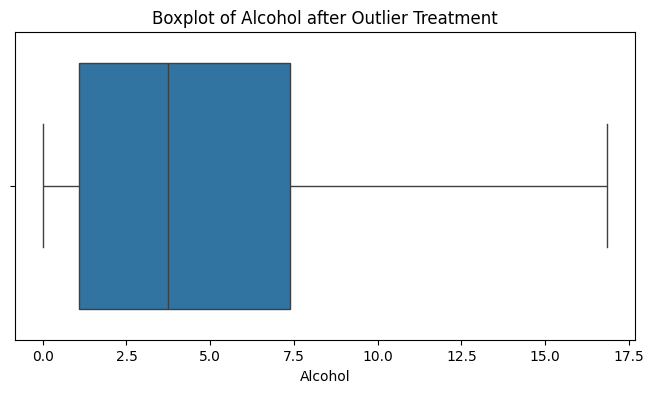

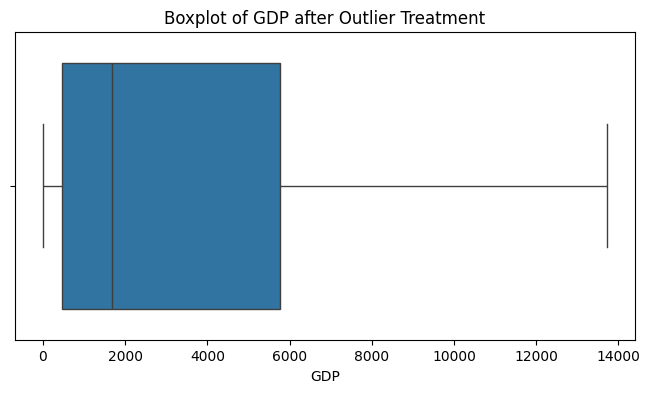

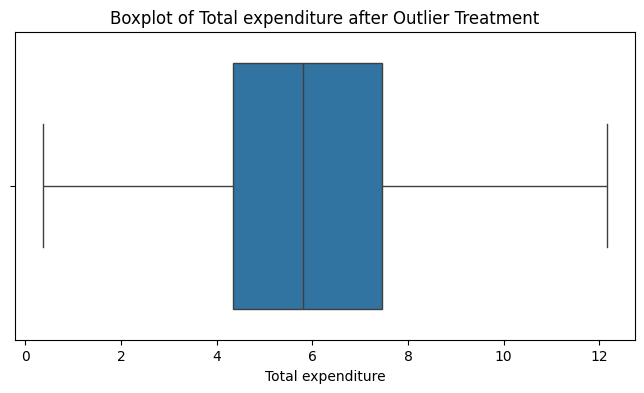

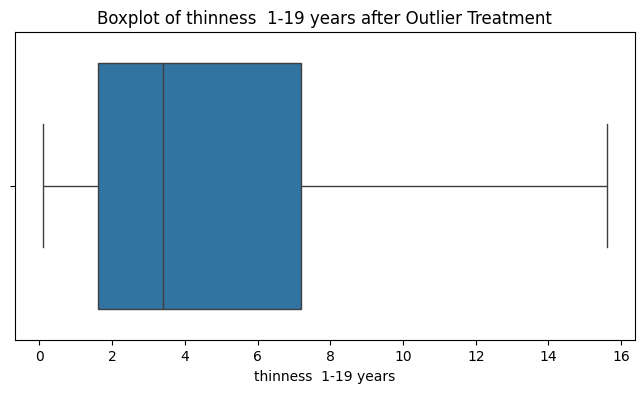

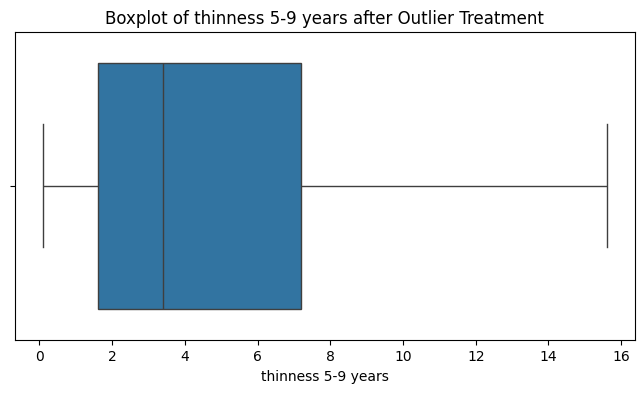

In [104]:
# ===============================
# STEP 5 — Outlier Treatment (IQR Method)
# ===============================
def wisker(col):
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    lw = q1 - 1.5 * iqr
    uw = q3 + 1.5 * iqr
    return lw, uw

outlier_cols = ['Alcohol', 'GDP', 'Total expenditure', 'thinness  1-19 years', 'thinness 5-9 years']

for col in outlier_cols:
    if col in df.columns:
        lw, uw = wisker(df[col])
        df[col] = np.where(df[col] < lw, lw, df[col])
        df[col] = np.where(df[col] > uw, uw, df[col])
        print(f"Outliers treated for: {col}")

print('\nBoxplots after outlier treatment for selected columns:')
for col in outlier_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col} after Outlier Treatment')
        plt.show()

In [111]:
# ===============================
# STEP 6 — Descriptive Statistics (EDA)
# ===============================
print('Descriptive Statistics for Numerical Features:')
display(df.describe().T)
# print('\nDescriptive Statistics for Object Features:')
# display(df.describe(include='object')) # Removed as there are no object columns left after encoding

Descriptive Statistics for Numerical Features:


,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy (men),2938.0,6.771001e+01,1.034622e+01,50.00000,59.000000,6.800000e+01,7.700000e+01,8.500000e+01
Life expectancy(women),2938.0,6.762934e+01,1.032524e+01,50.00000,59.000000,6.750000e+01,7.600000e+01,8.500000e+01
Adult Mortality (men),2938.0,7.473281e+01,1.472887e+01,50.00000,62.000000,7.450000e+01,8.700000e+01,1.000000e+02
Adult Mortality (women),2938.0,7.455820e+01,1.468206e+01,50.00000,62.000000,7.400000e+01,8.700000e+01,1.000000e+02
Infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2938.0,4.546310e+00,3.920116e+00,0.01000,1.092500,3.755000e+00,7.390000e+00,1.683625e+01
Percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B(men),2938.0,4.601157e+01,1.655874e+01,18.00000,31.000000,4.600000e+01,6.000000e+01,7.500000e+01
Hepatitis B(women),2938.0,4.646971e+01,1.689127e+01,18.00000,32.000000,4.600000e+01,6.100000e+01,7.500000e+01


Histograms for Numerical Features:


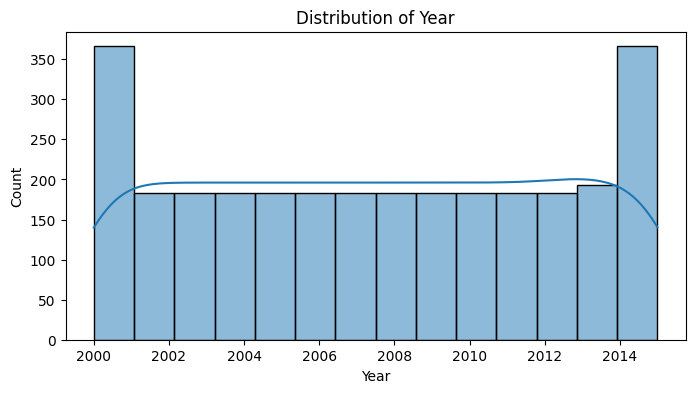

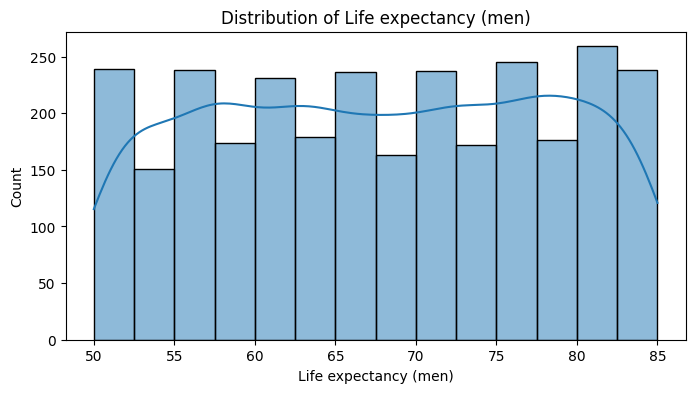

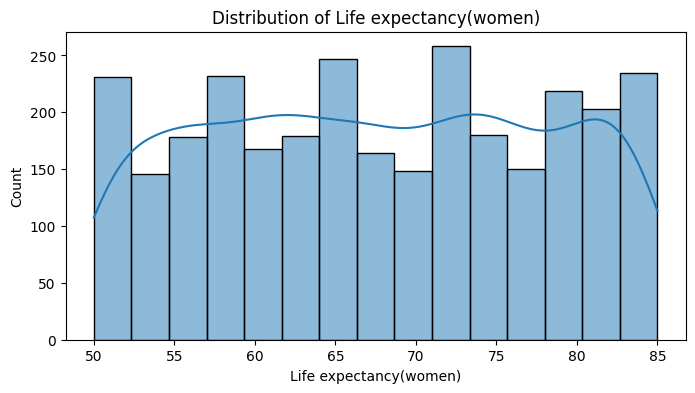

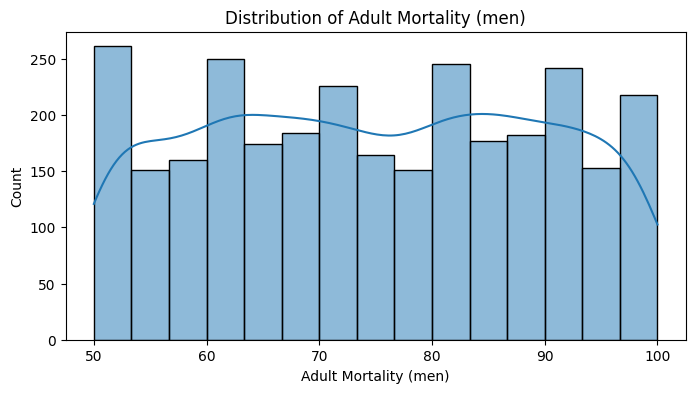

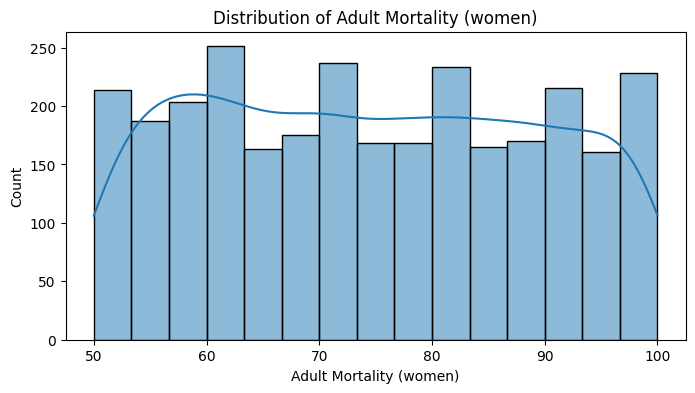

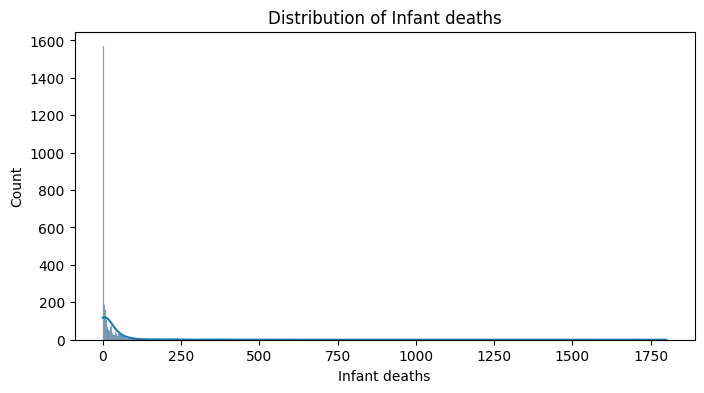

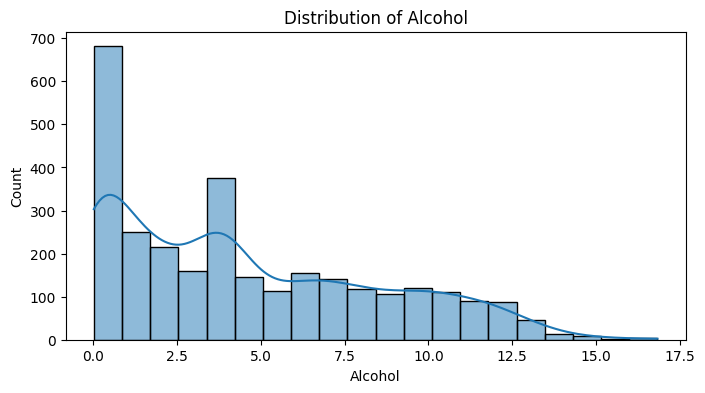

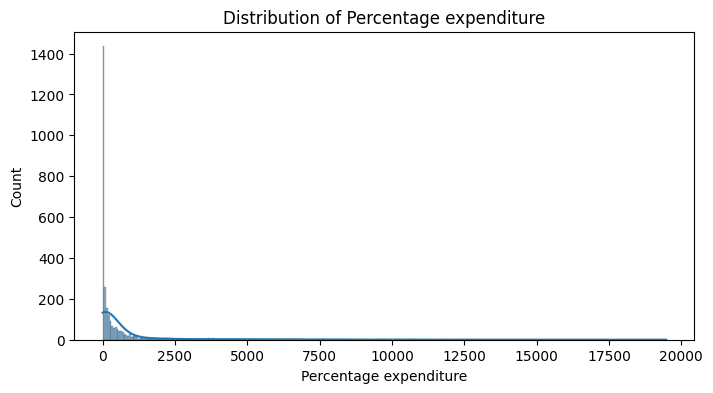

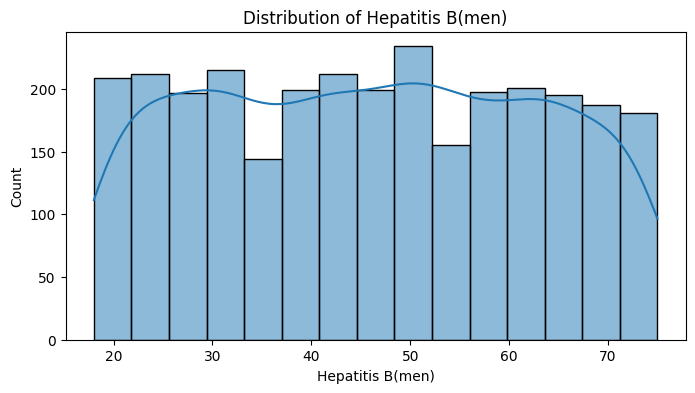

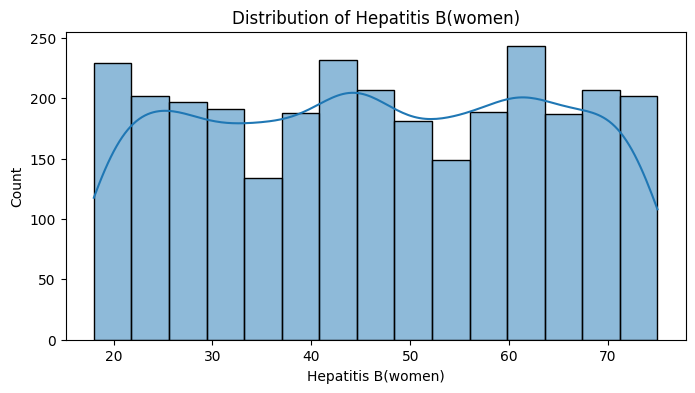

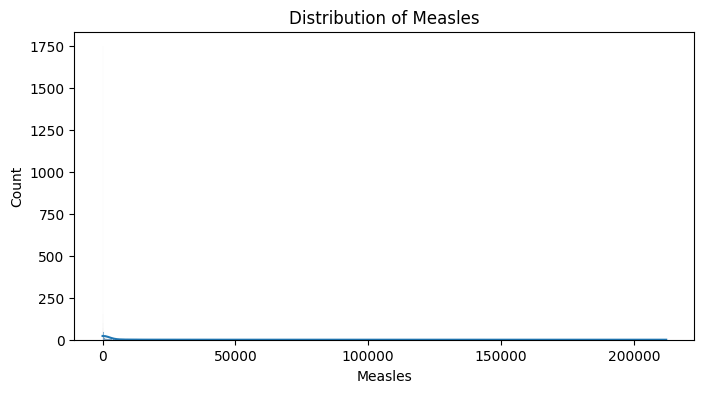

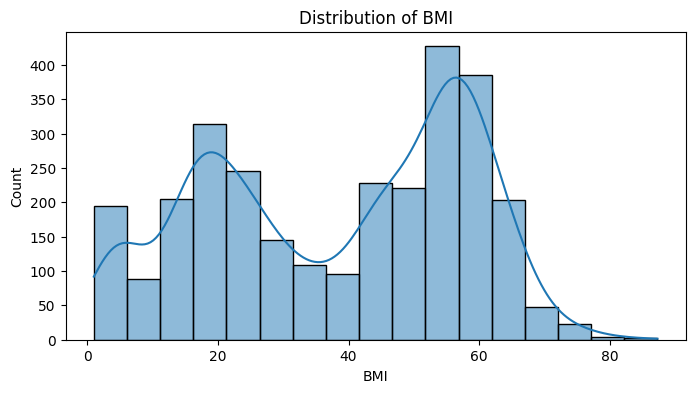

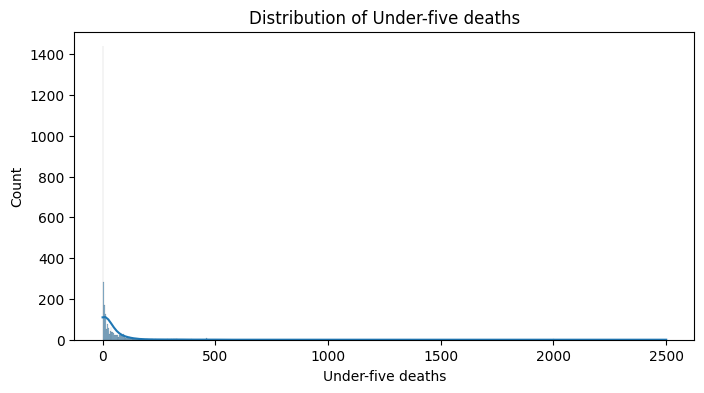

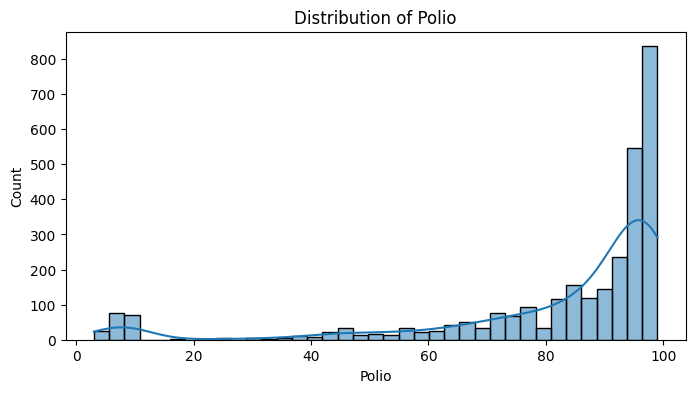

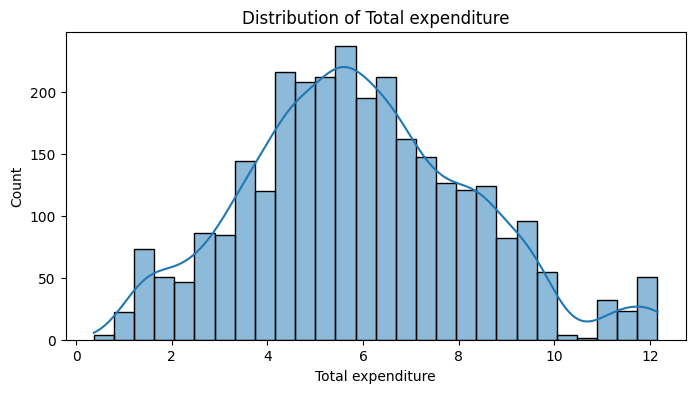

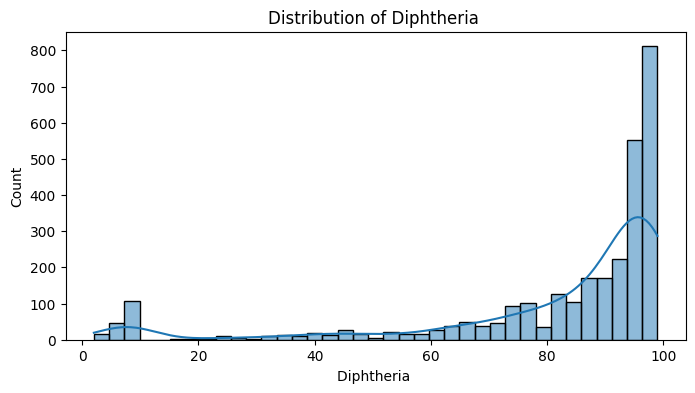

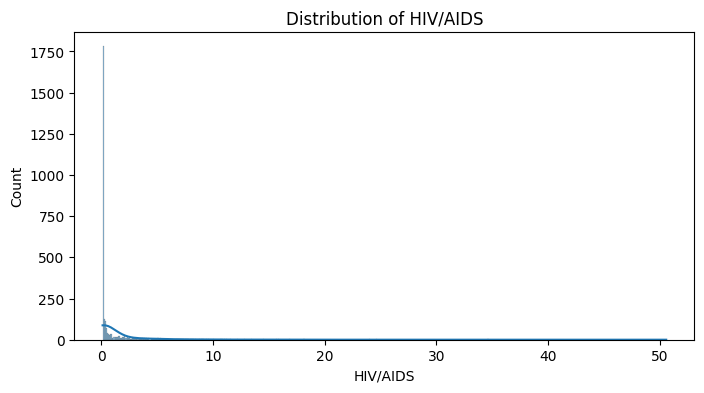

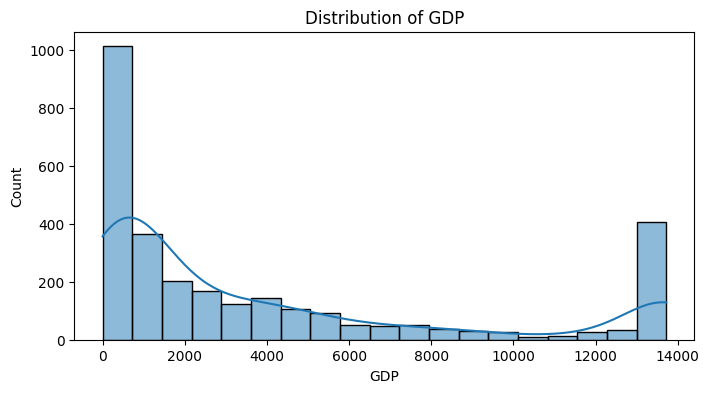

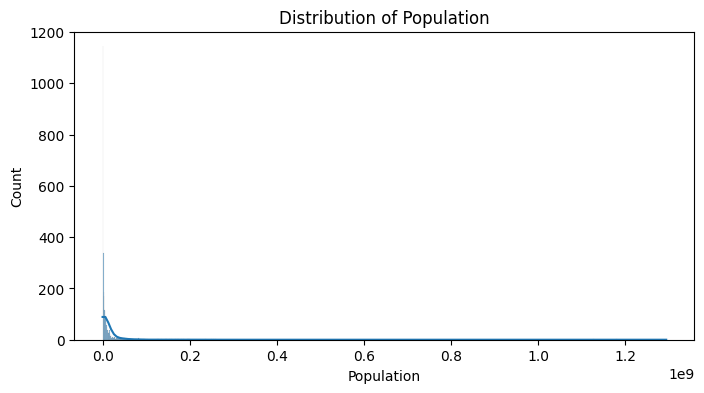

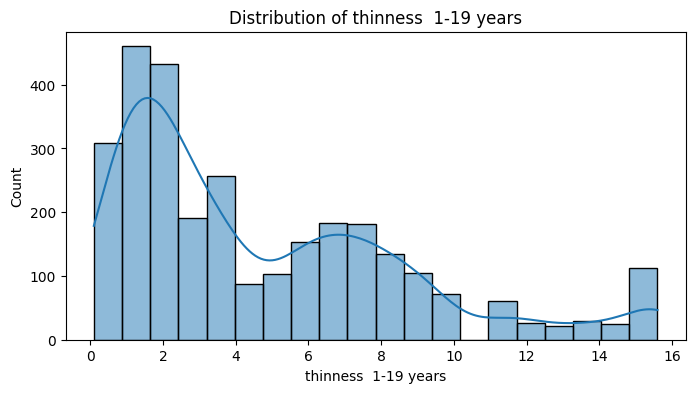

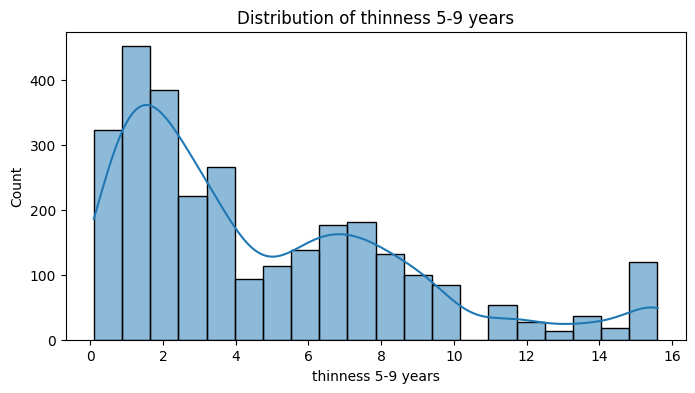

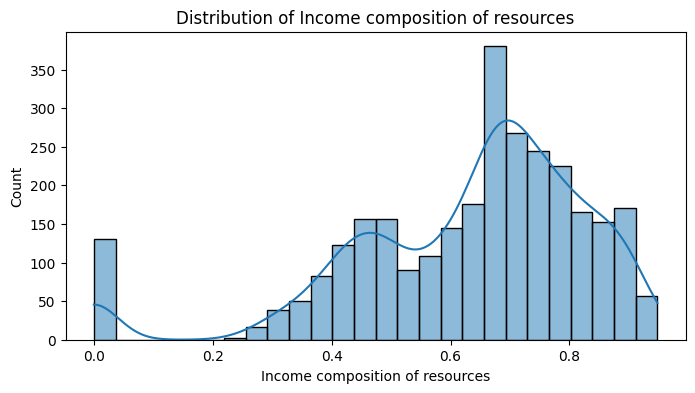

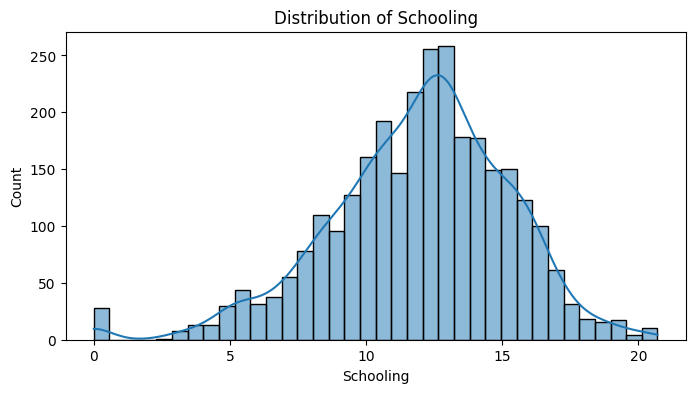

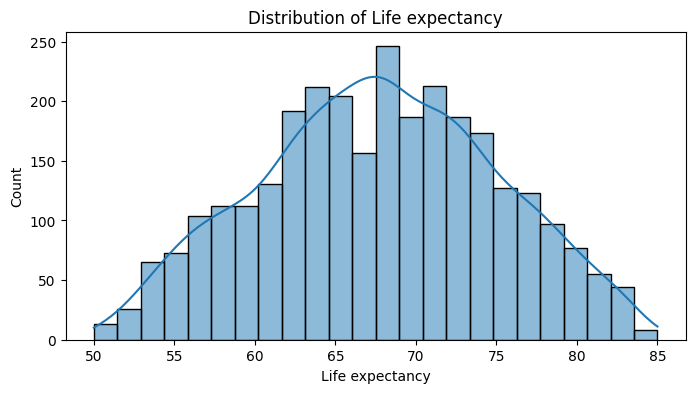

In [106]:
# ===============================
# STEP 6 — Histograms (EDA)
# ===============================
print('Histograms for Numerical Features:')
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

Boxplots for Numerical Features:


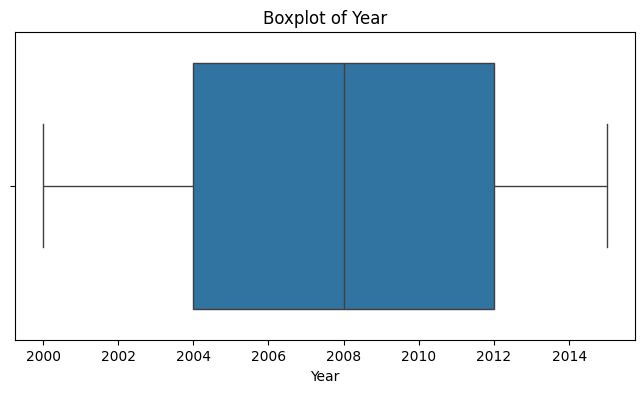

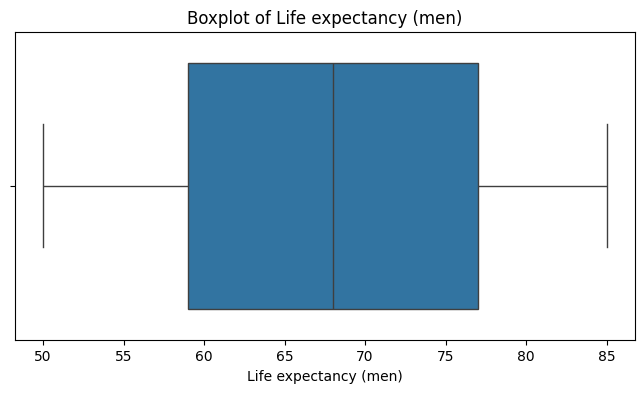

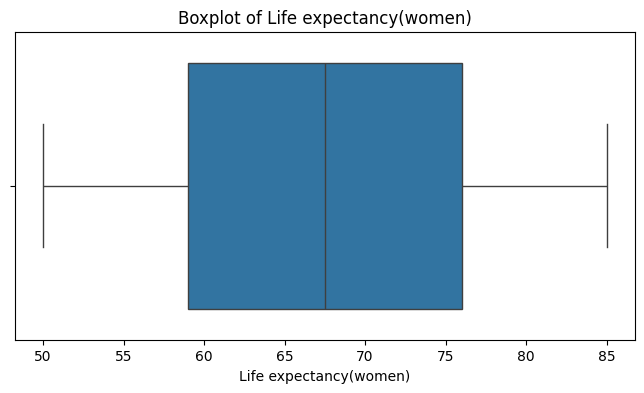

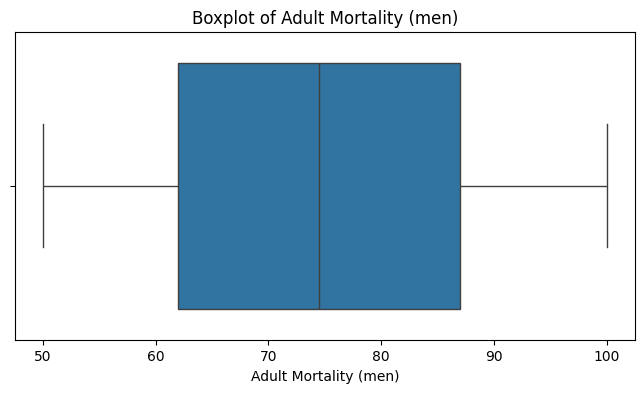

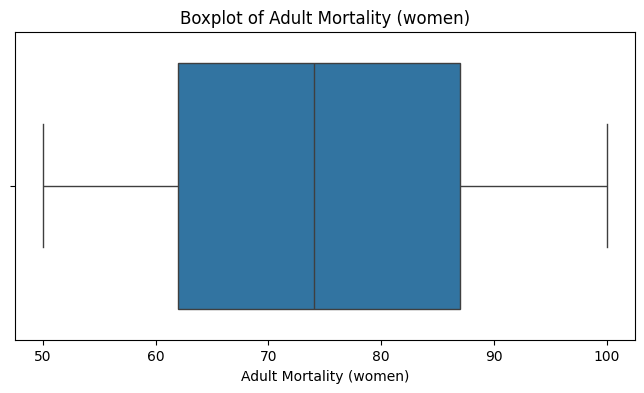

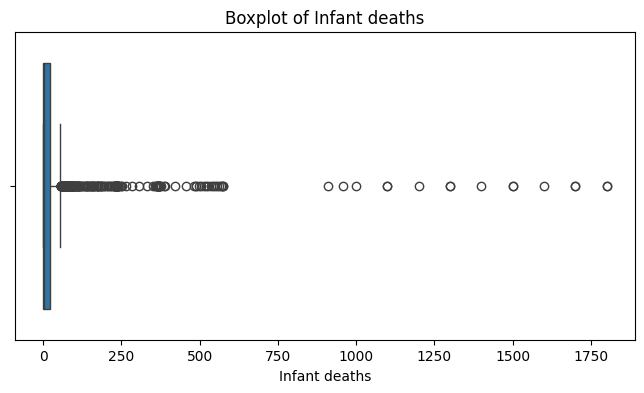

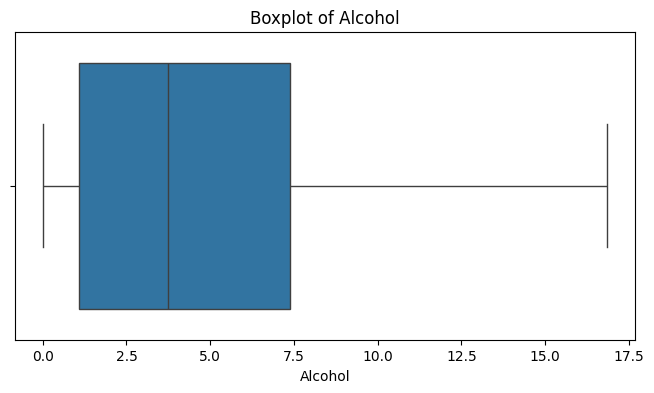

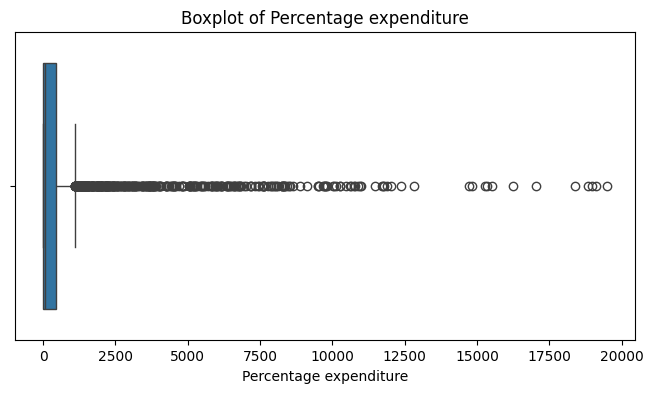

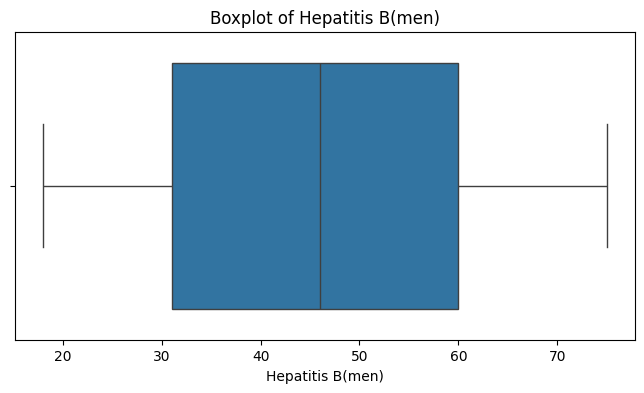

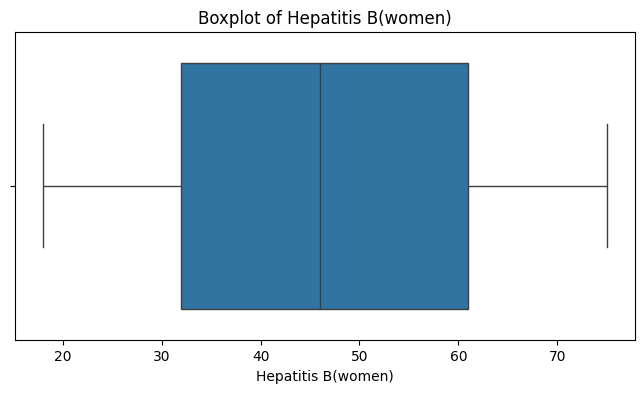

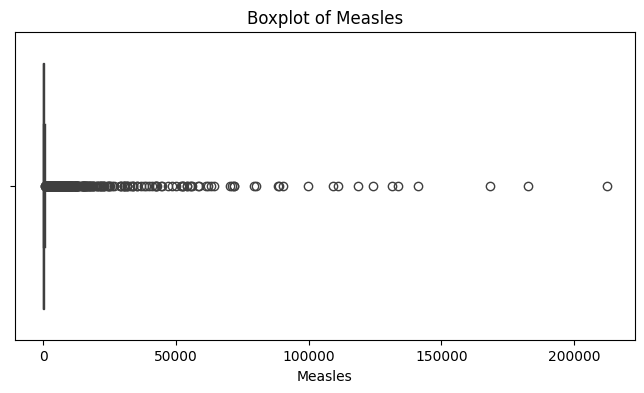

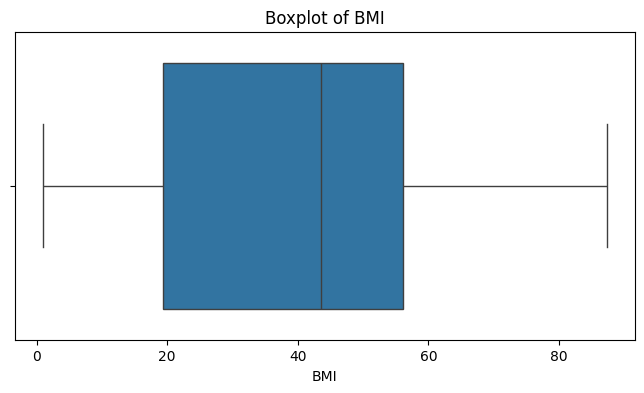

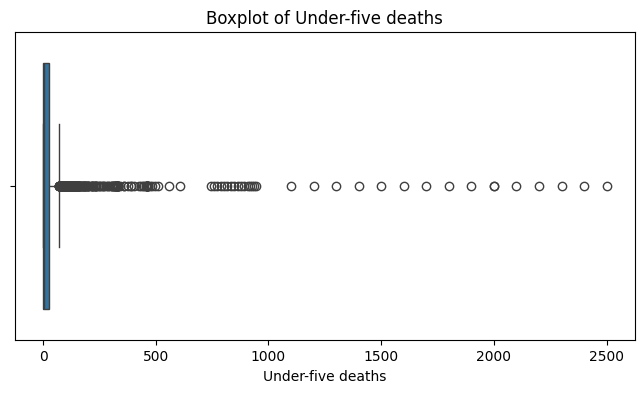

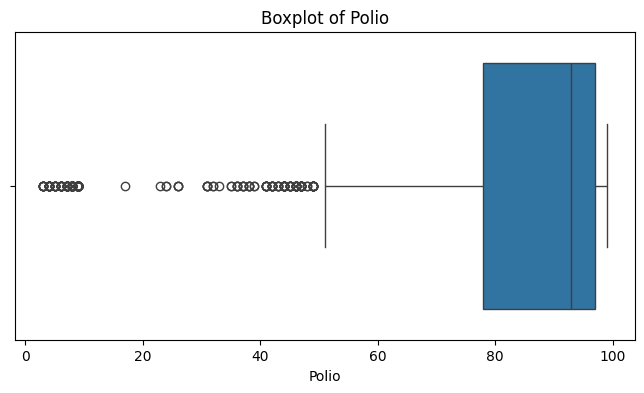

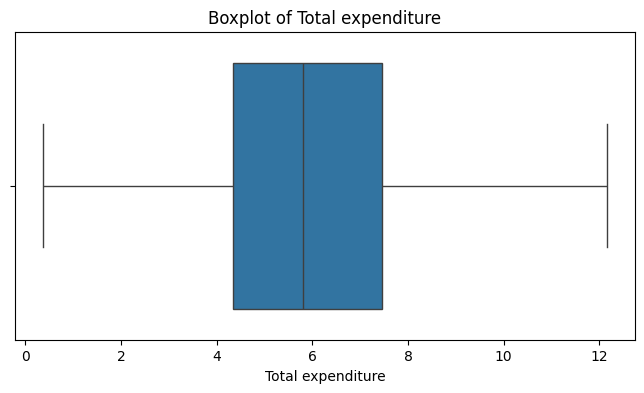

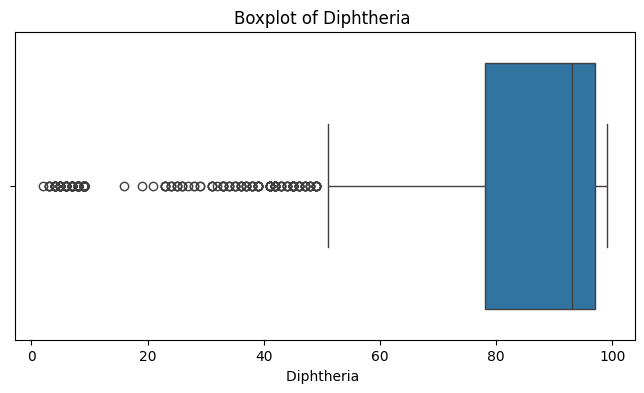

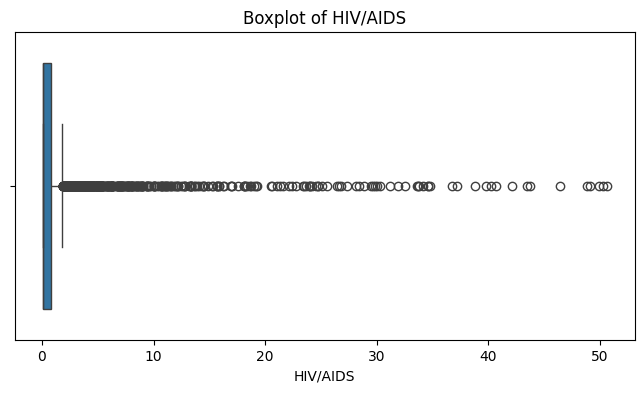

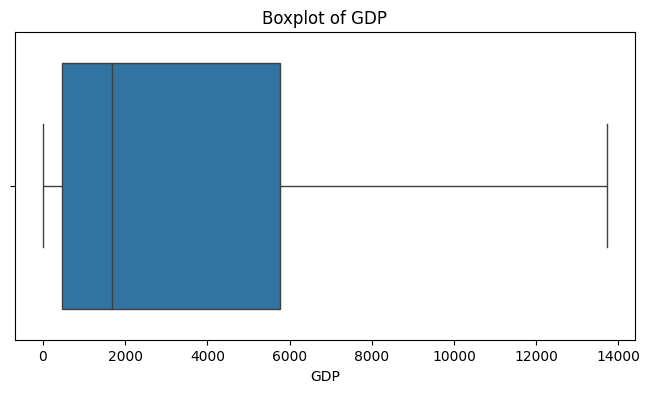

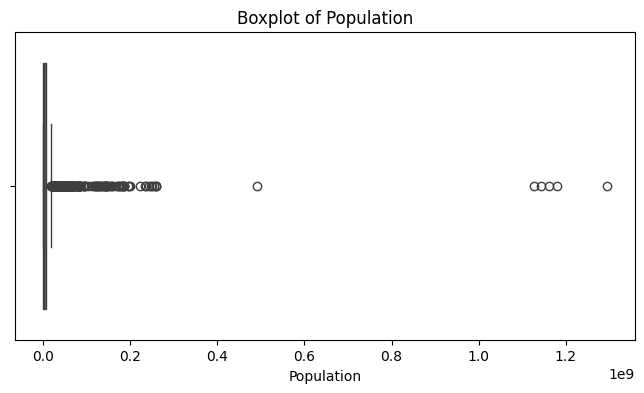

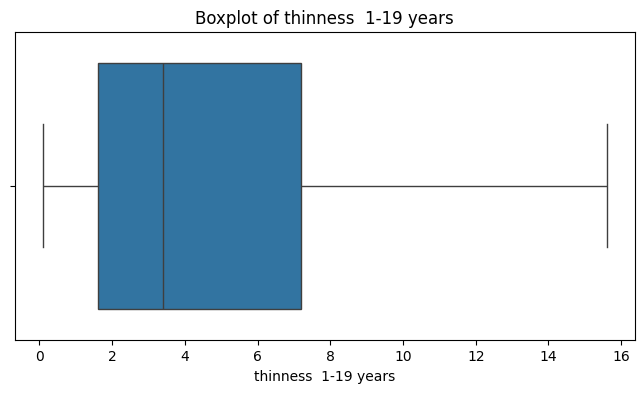

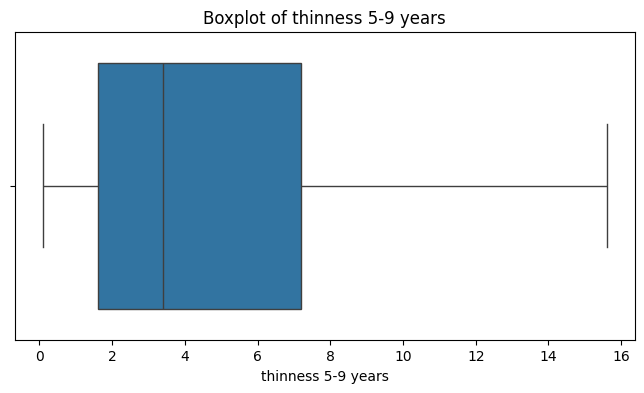

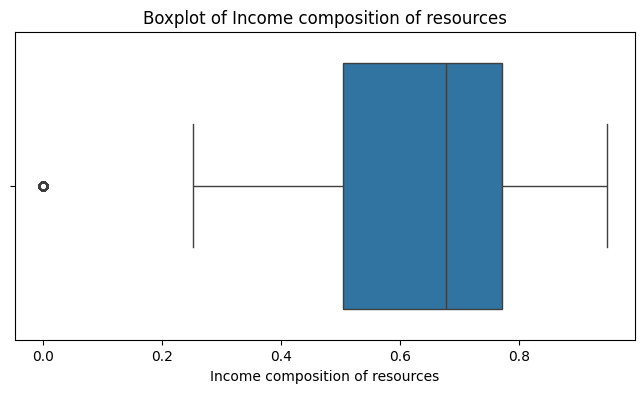

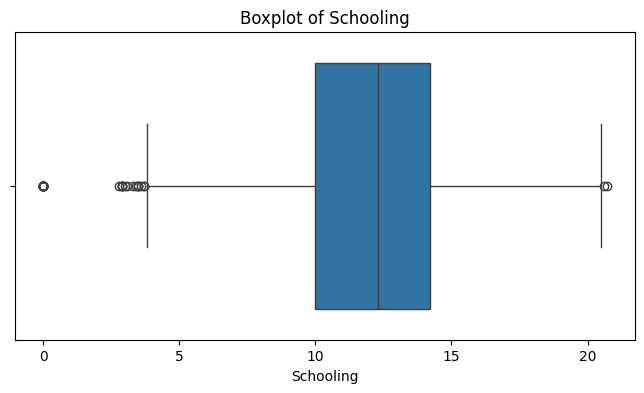

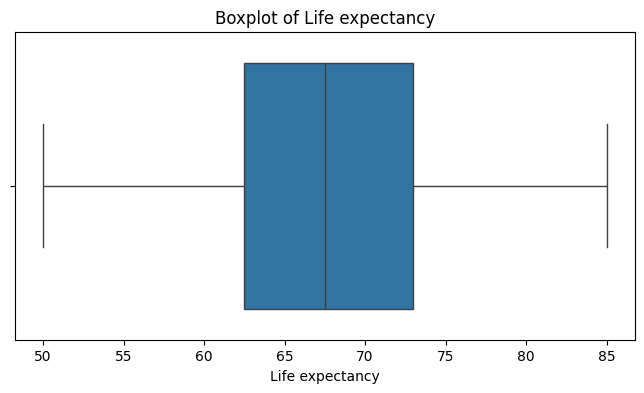

In [107]:
# ===============================
# STEP 6 — Boxplots (EDA)
# ===============================
print('Boxplots for Numerical Features:')
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

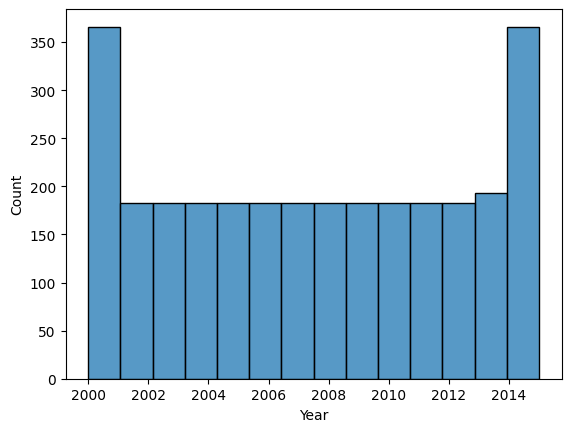

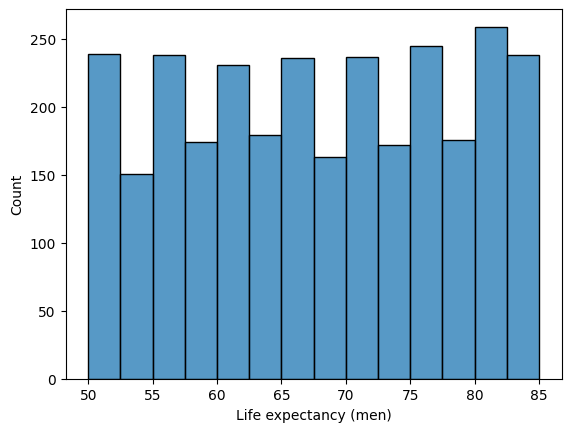

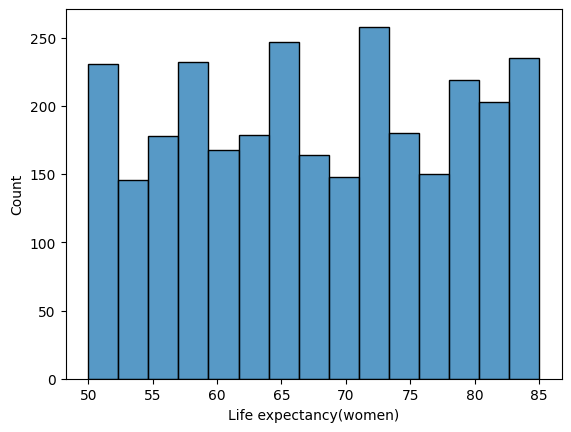

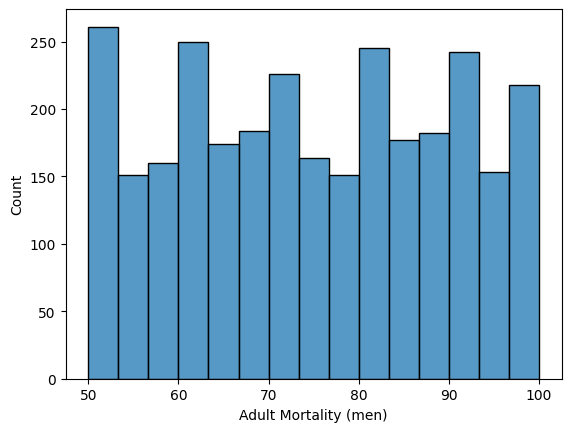

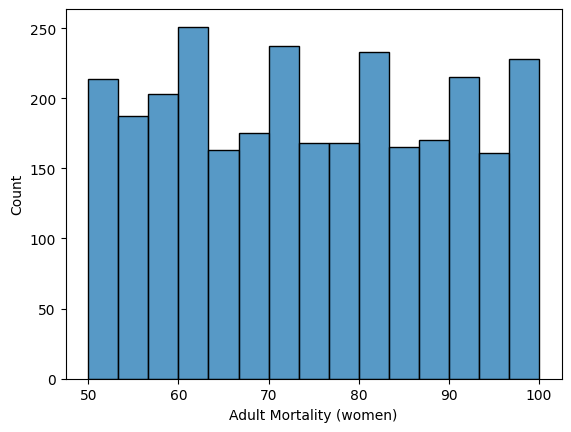

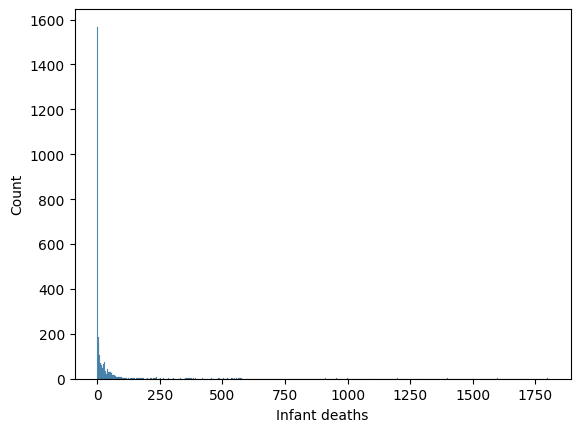

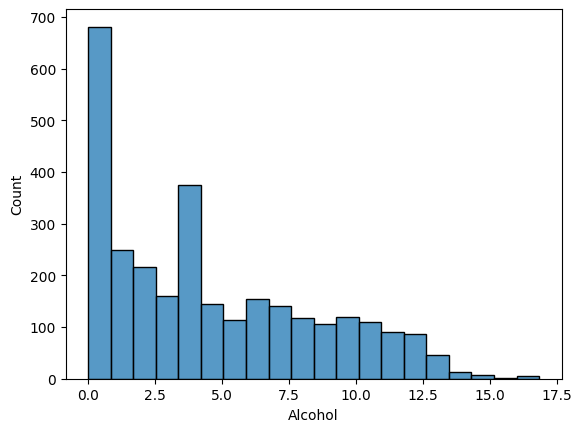

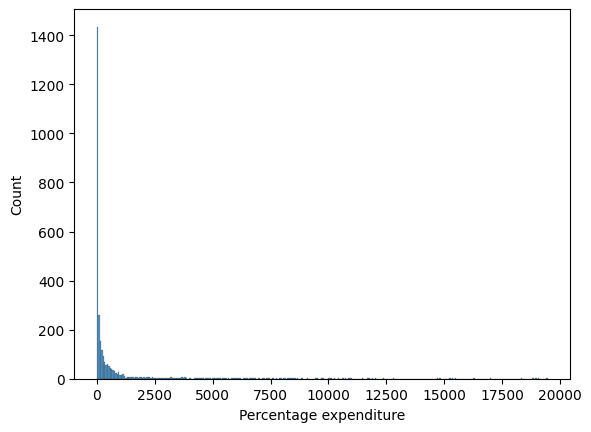

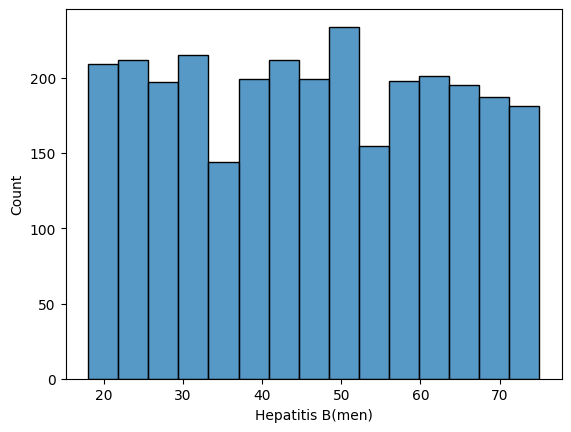

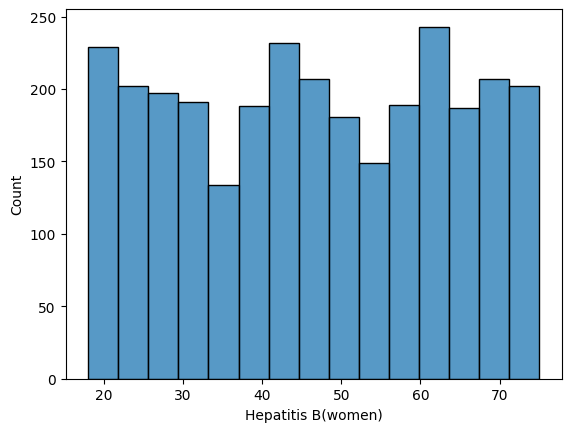

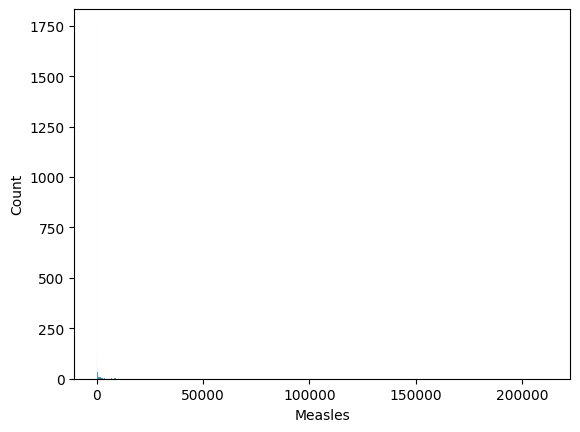

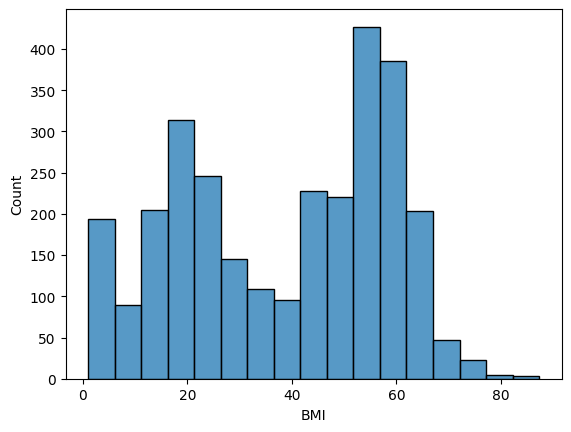

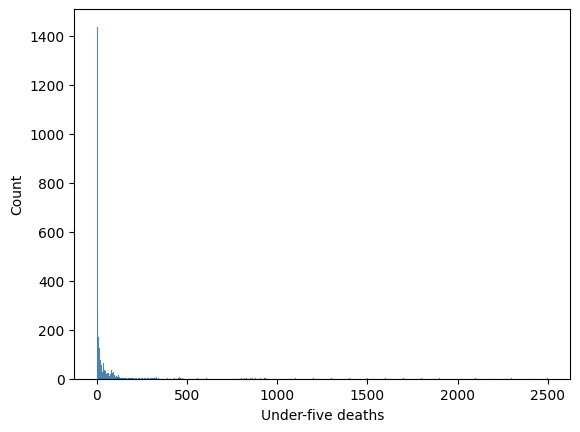

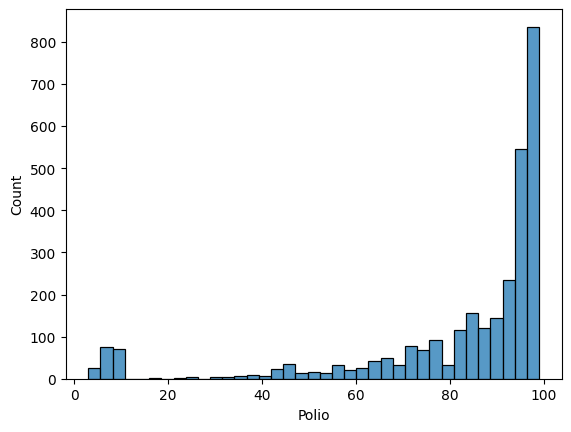

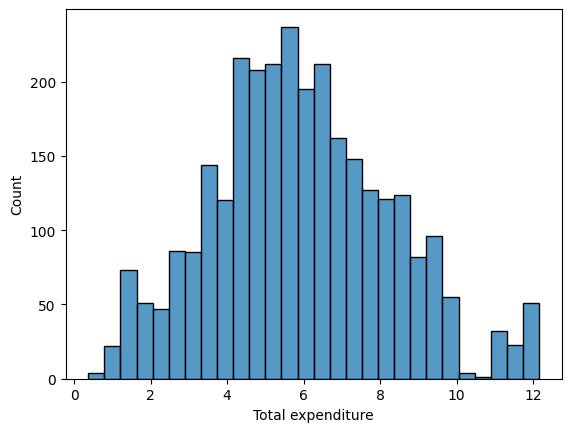

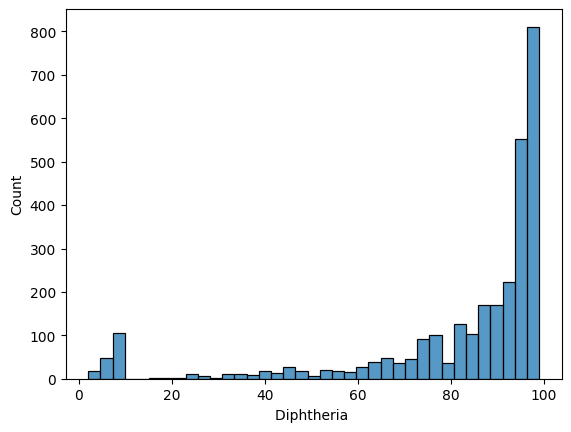

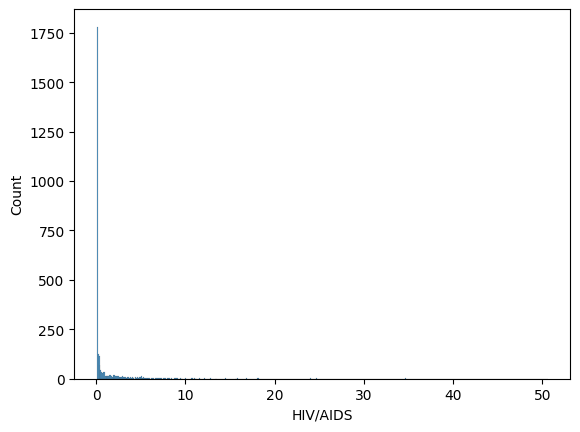

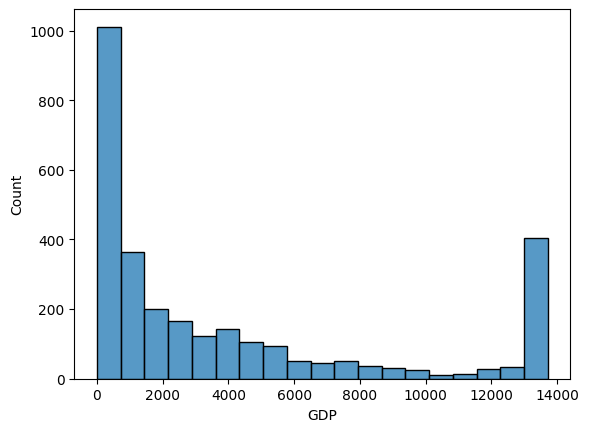

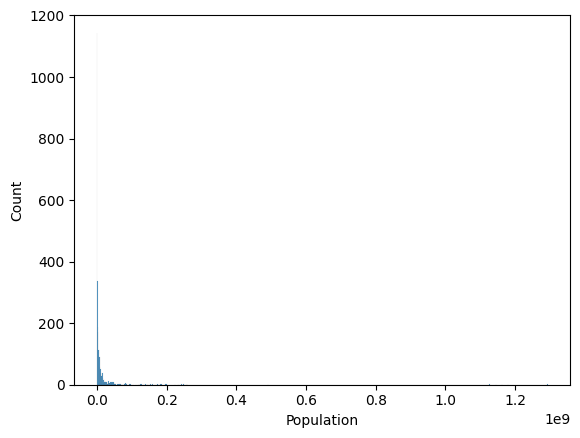

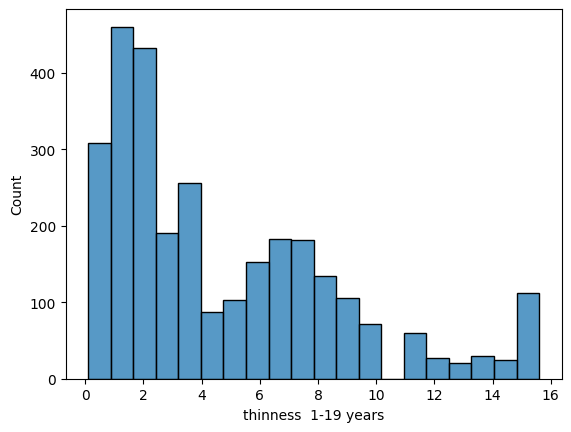

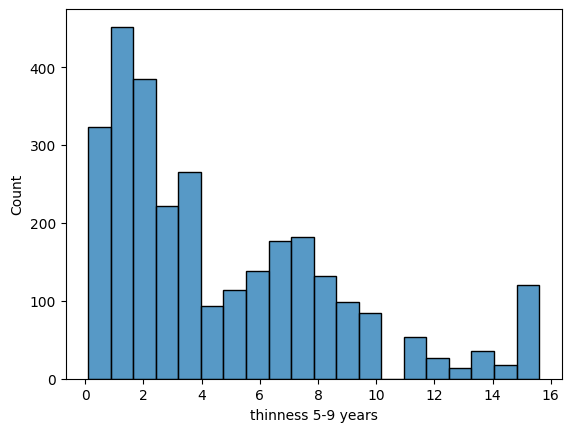

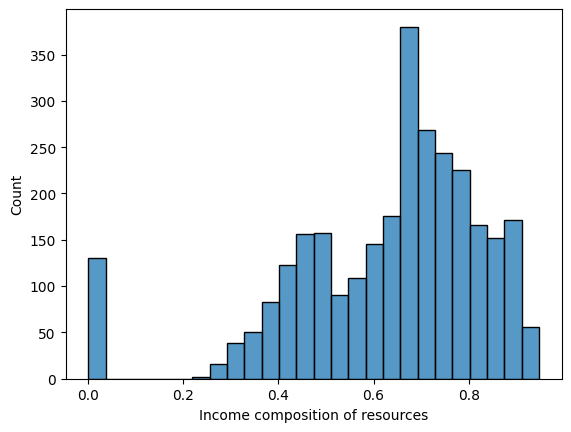

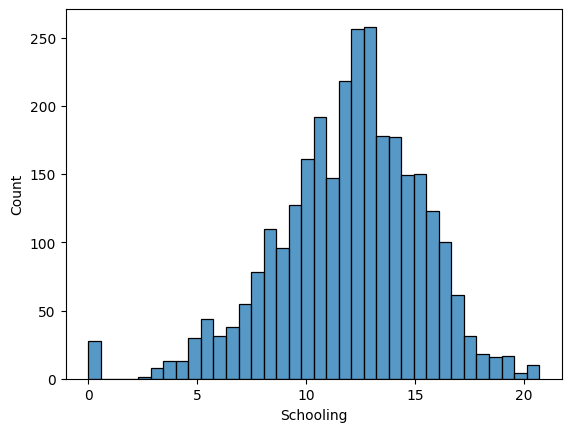

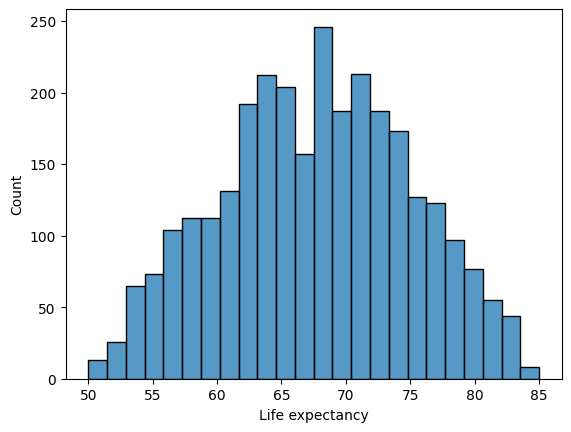

In [91]:
# Histograms
for col in df.select_dtypes(include="number").columns:
    sns.histplot(data=df, x=col)
    plt.show()

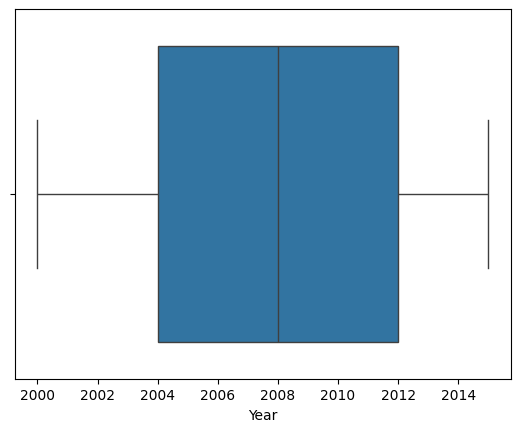

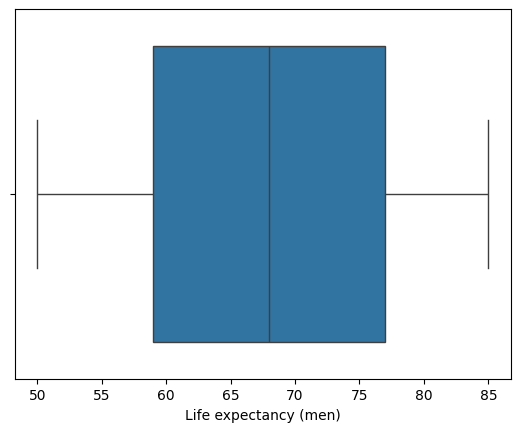

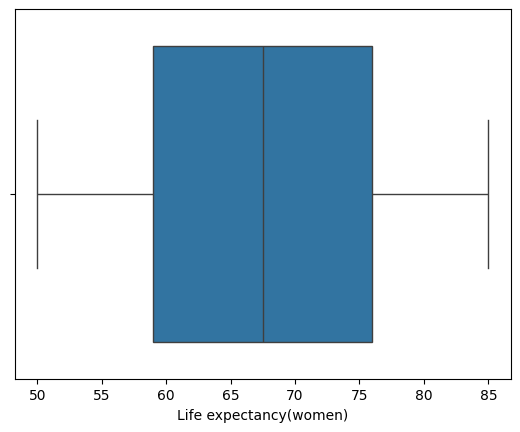

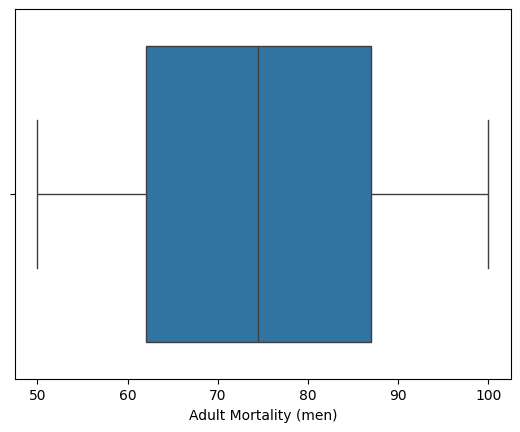

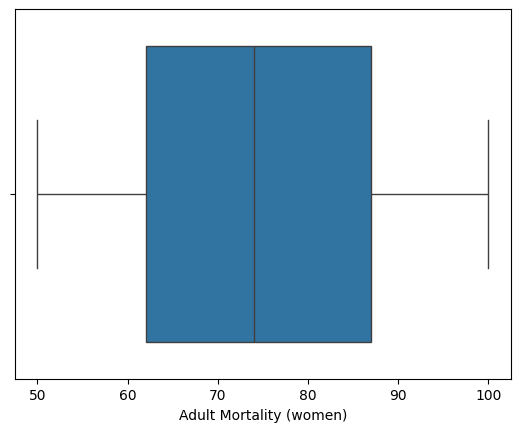

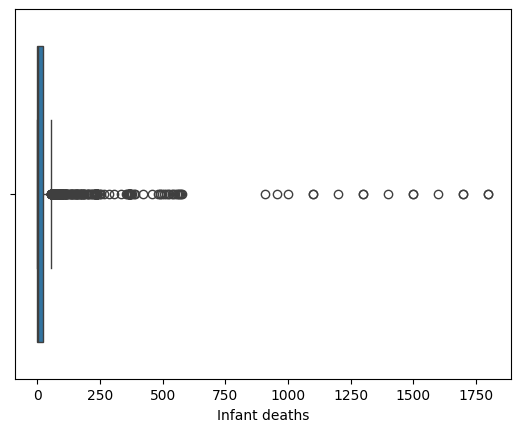

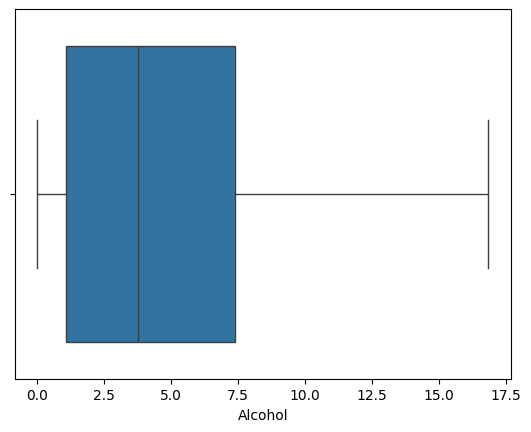

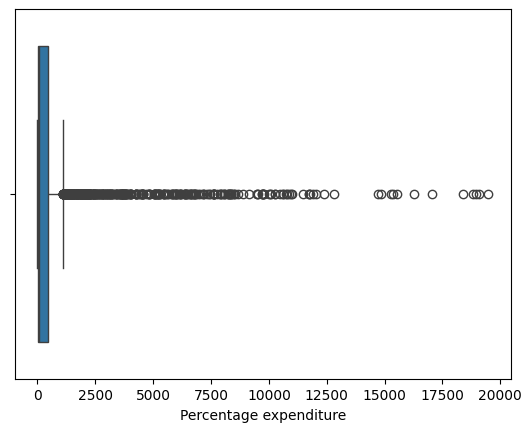

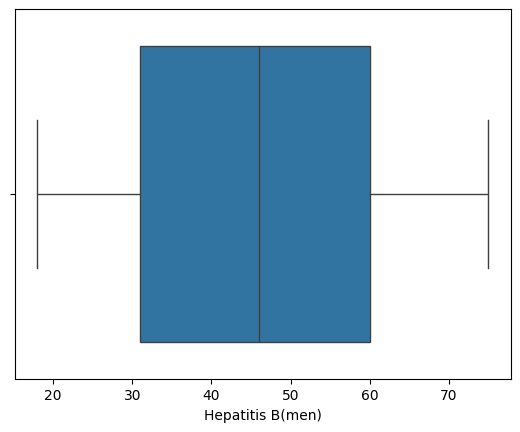

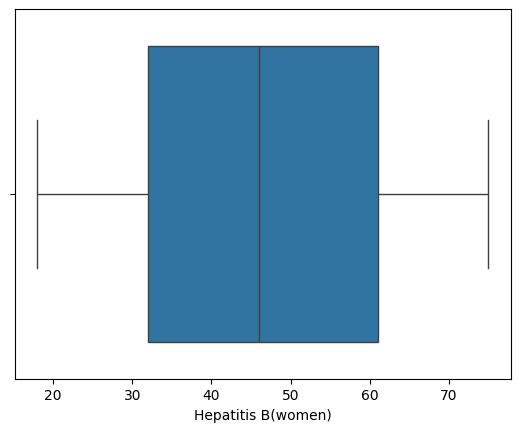

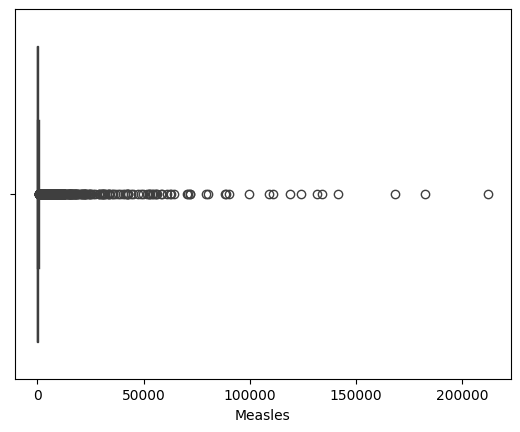

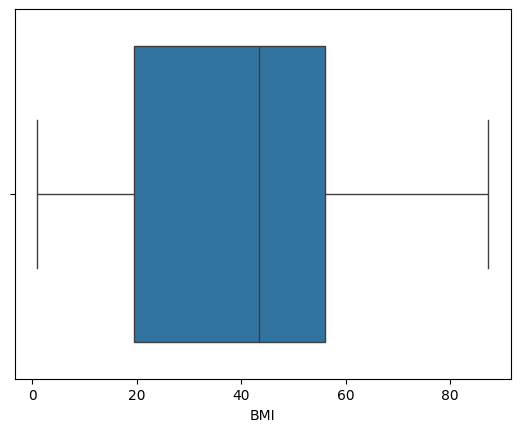

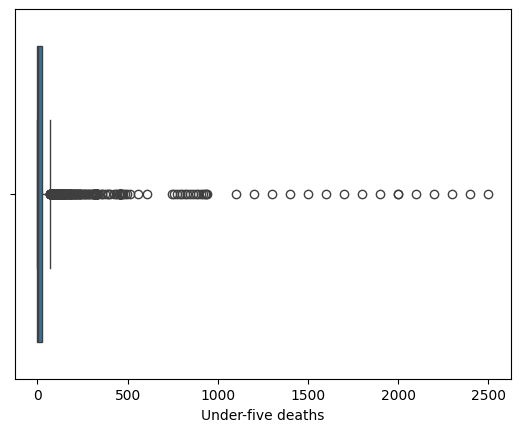

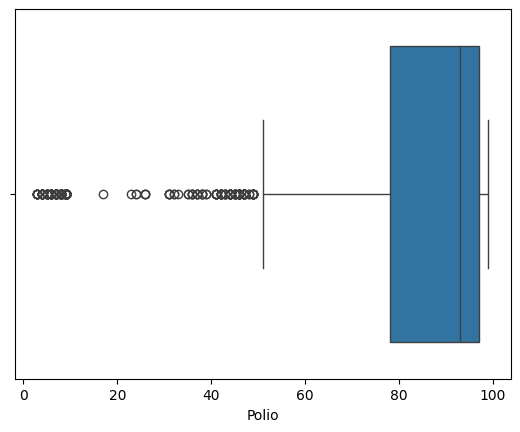

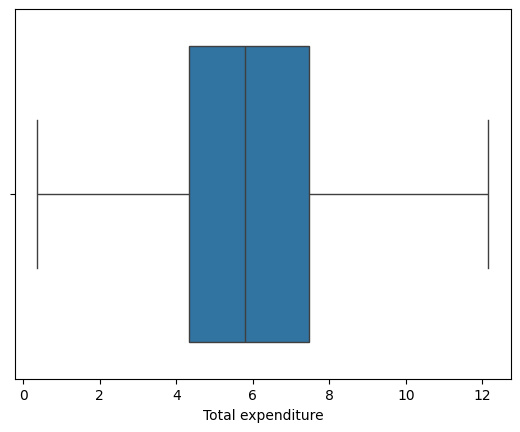

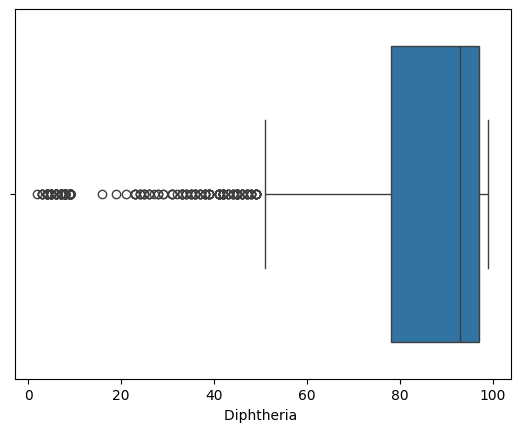

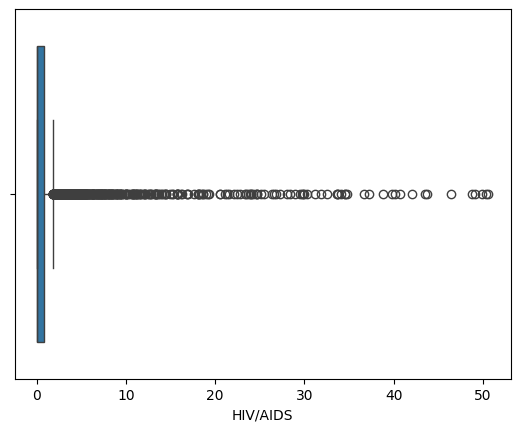

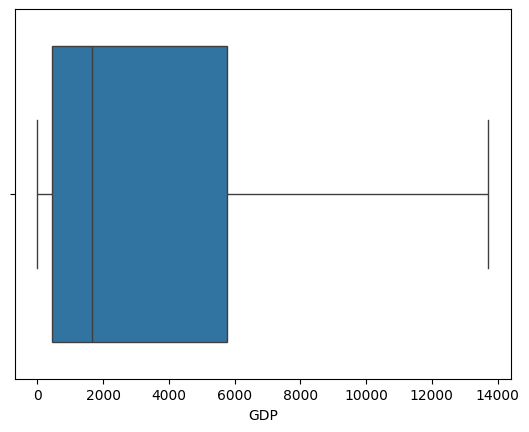

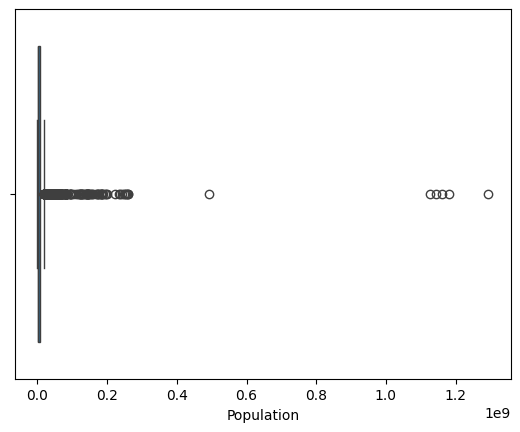

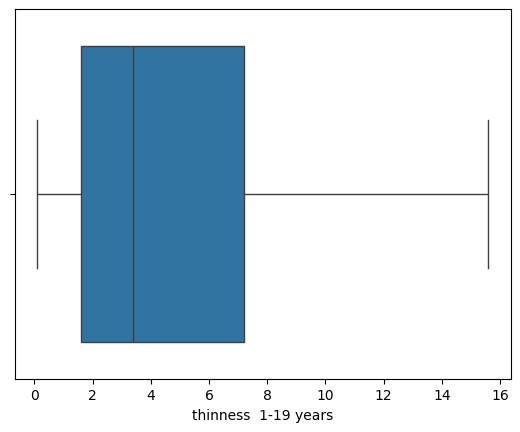

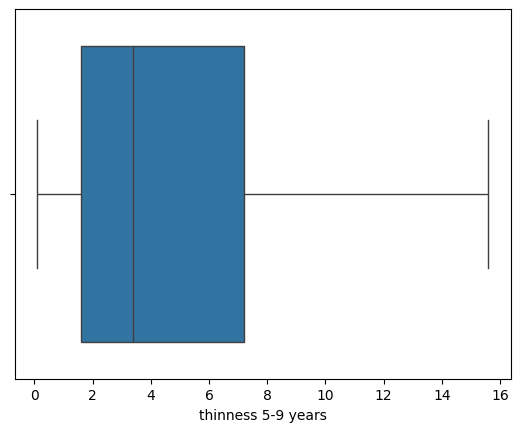

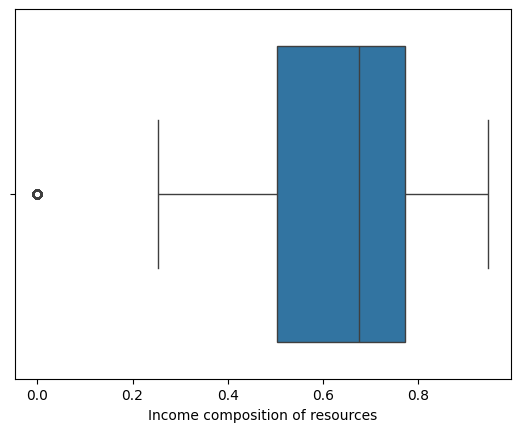

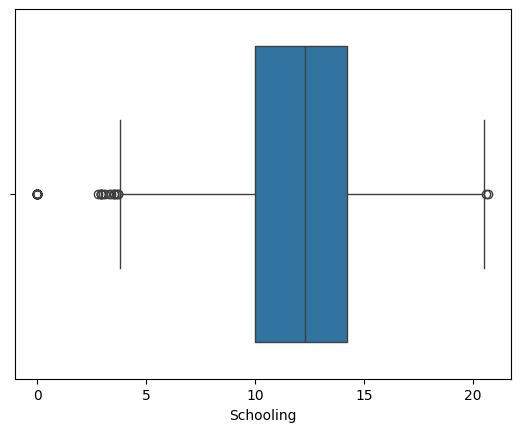

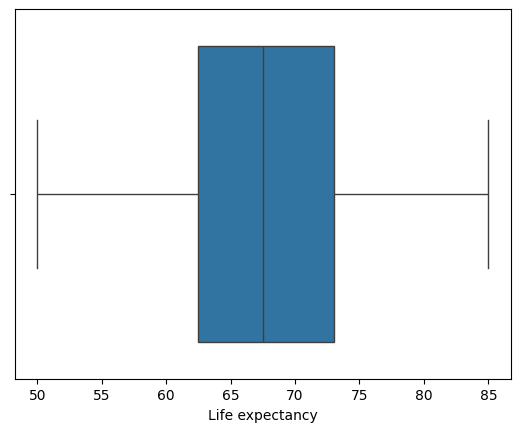

In [92]:
# Boxplots
for col in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df, x=col)
    plt.show()

Scatterplots vs. Life Expectancy:


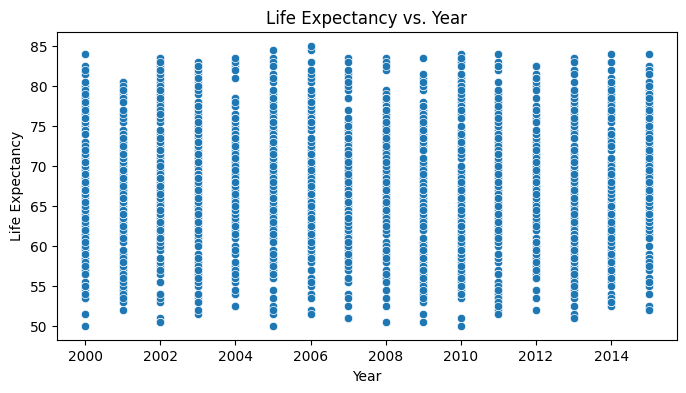

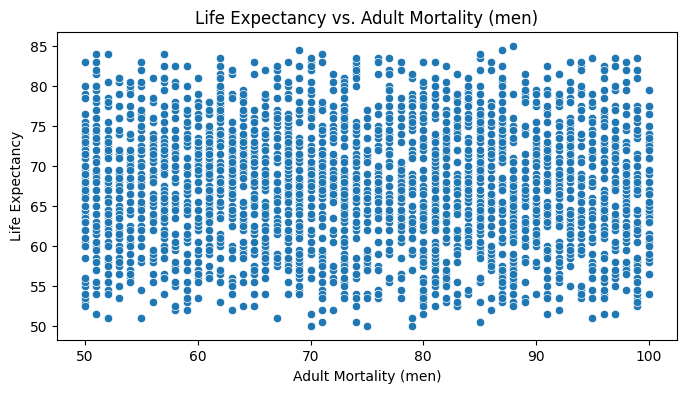

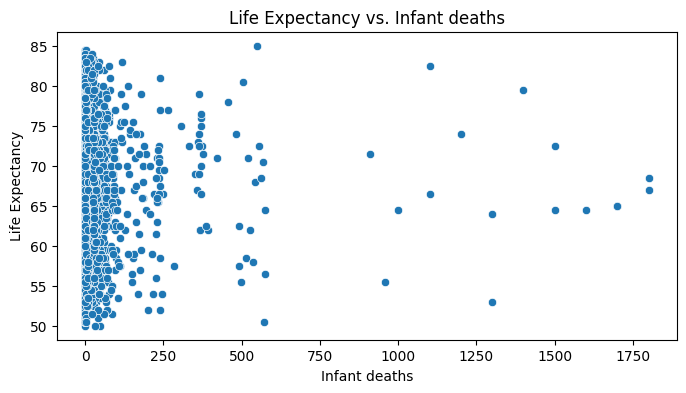

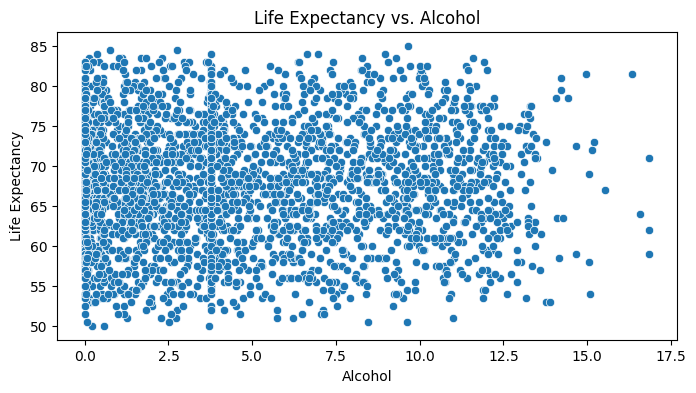

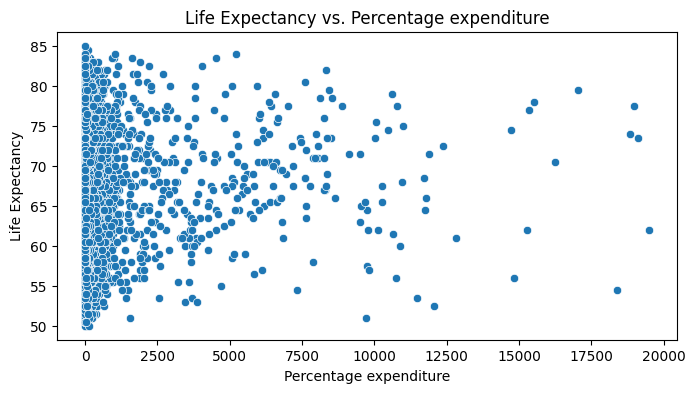

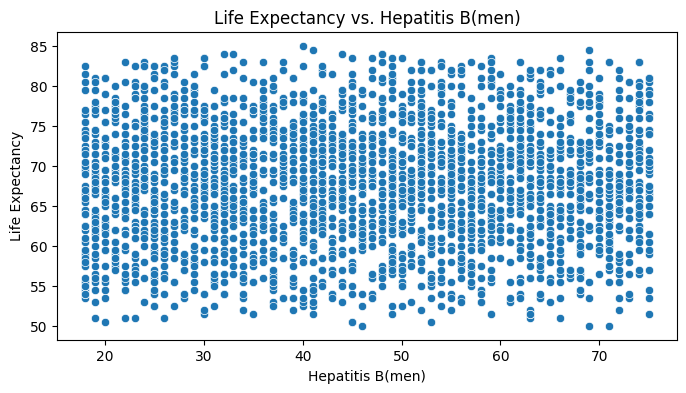

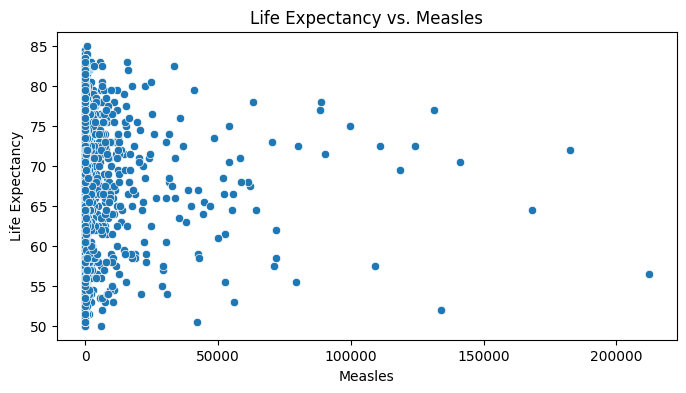

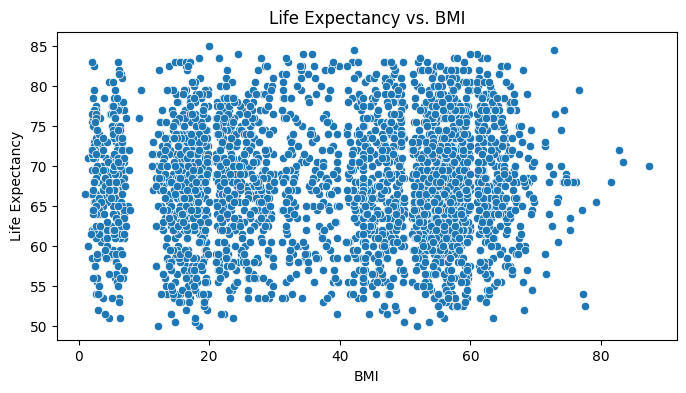

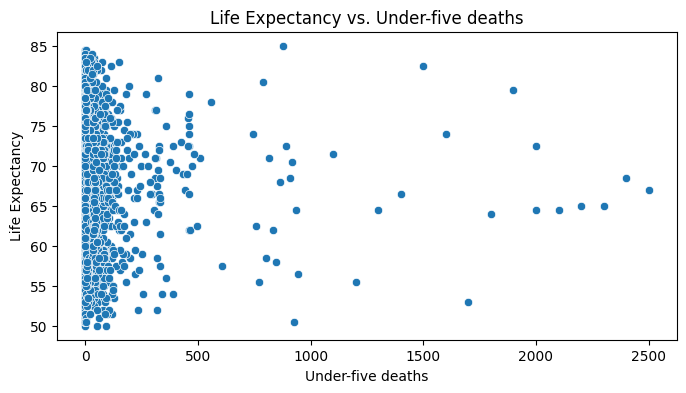

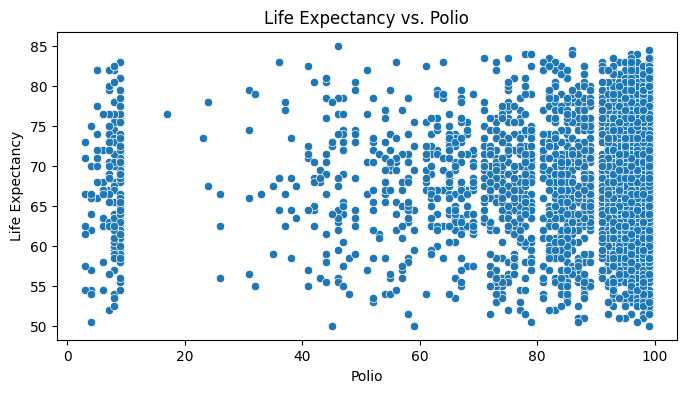

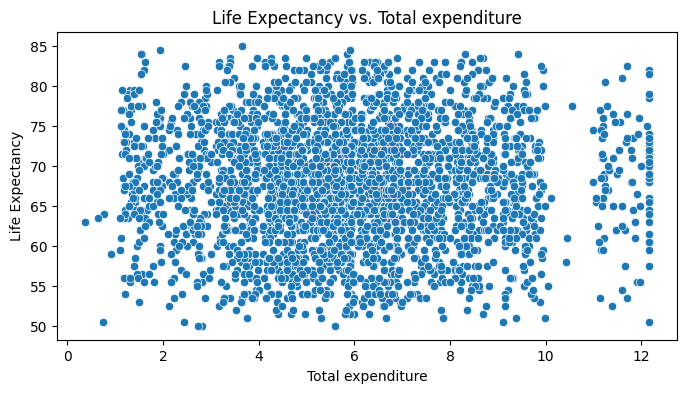

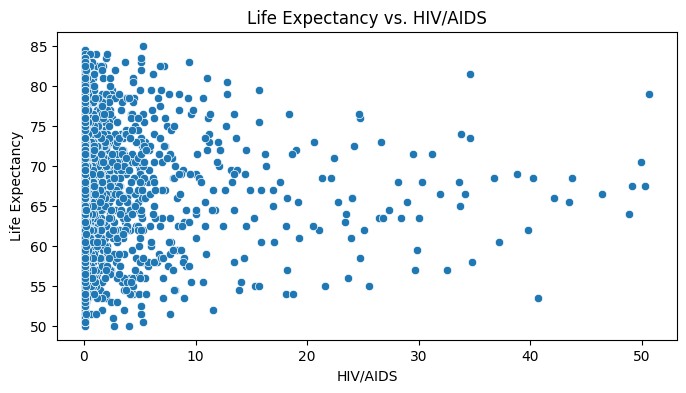

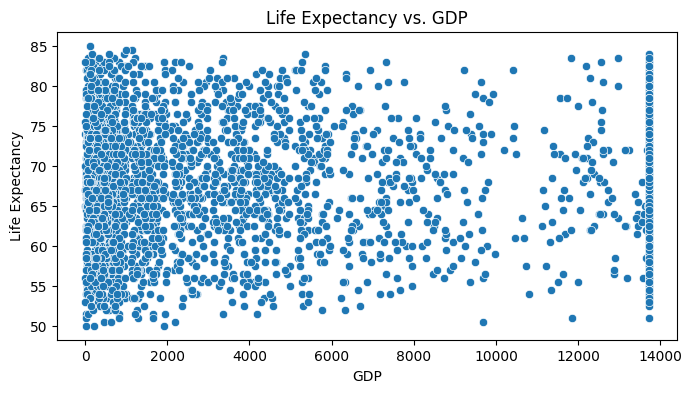

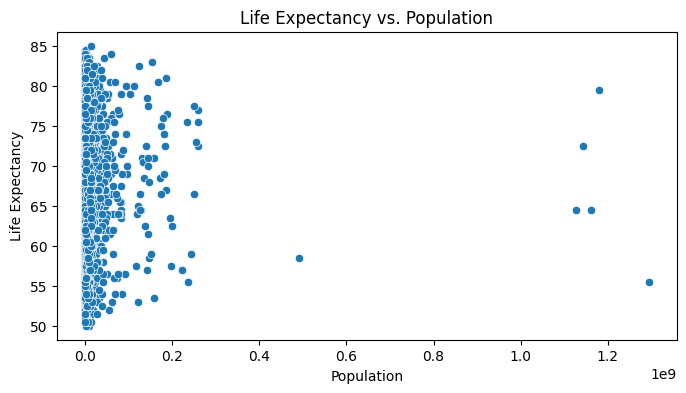

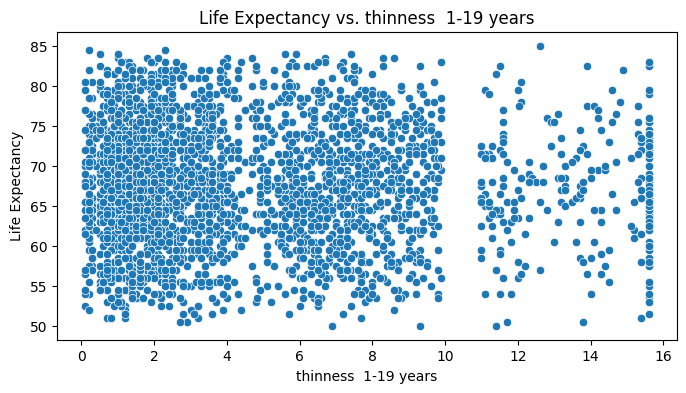

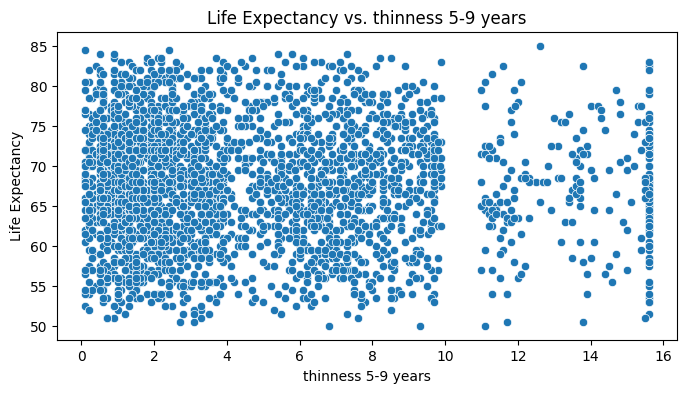

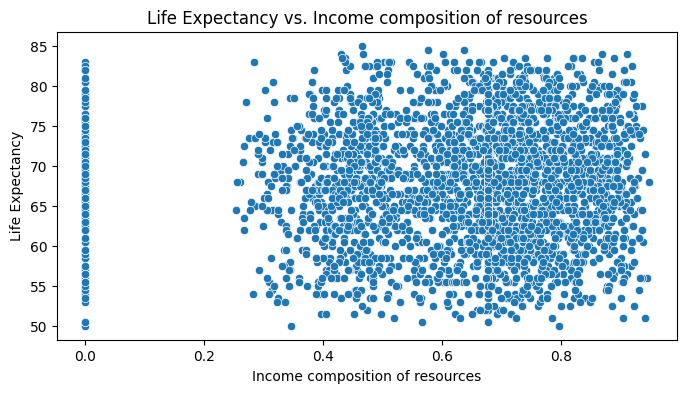

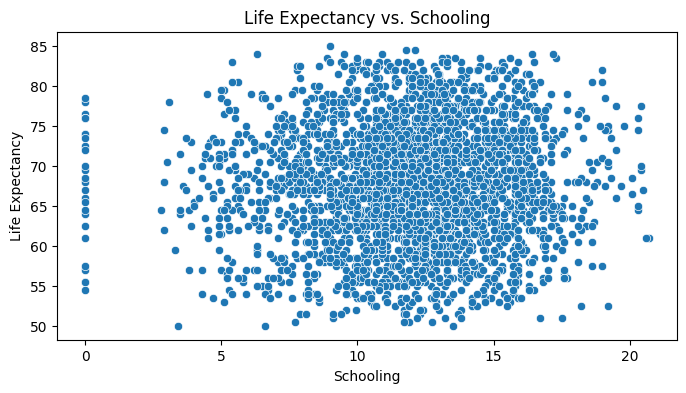


Correlation Heatmap of Numerical Features:


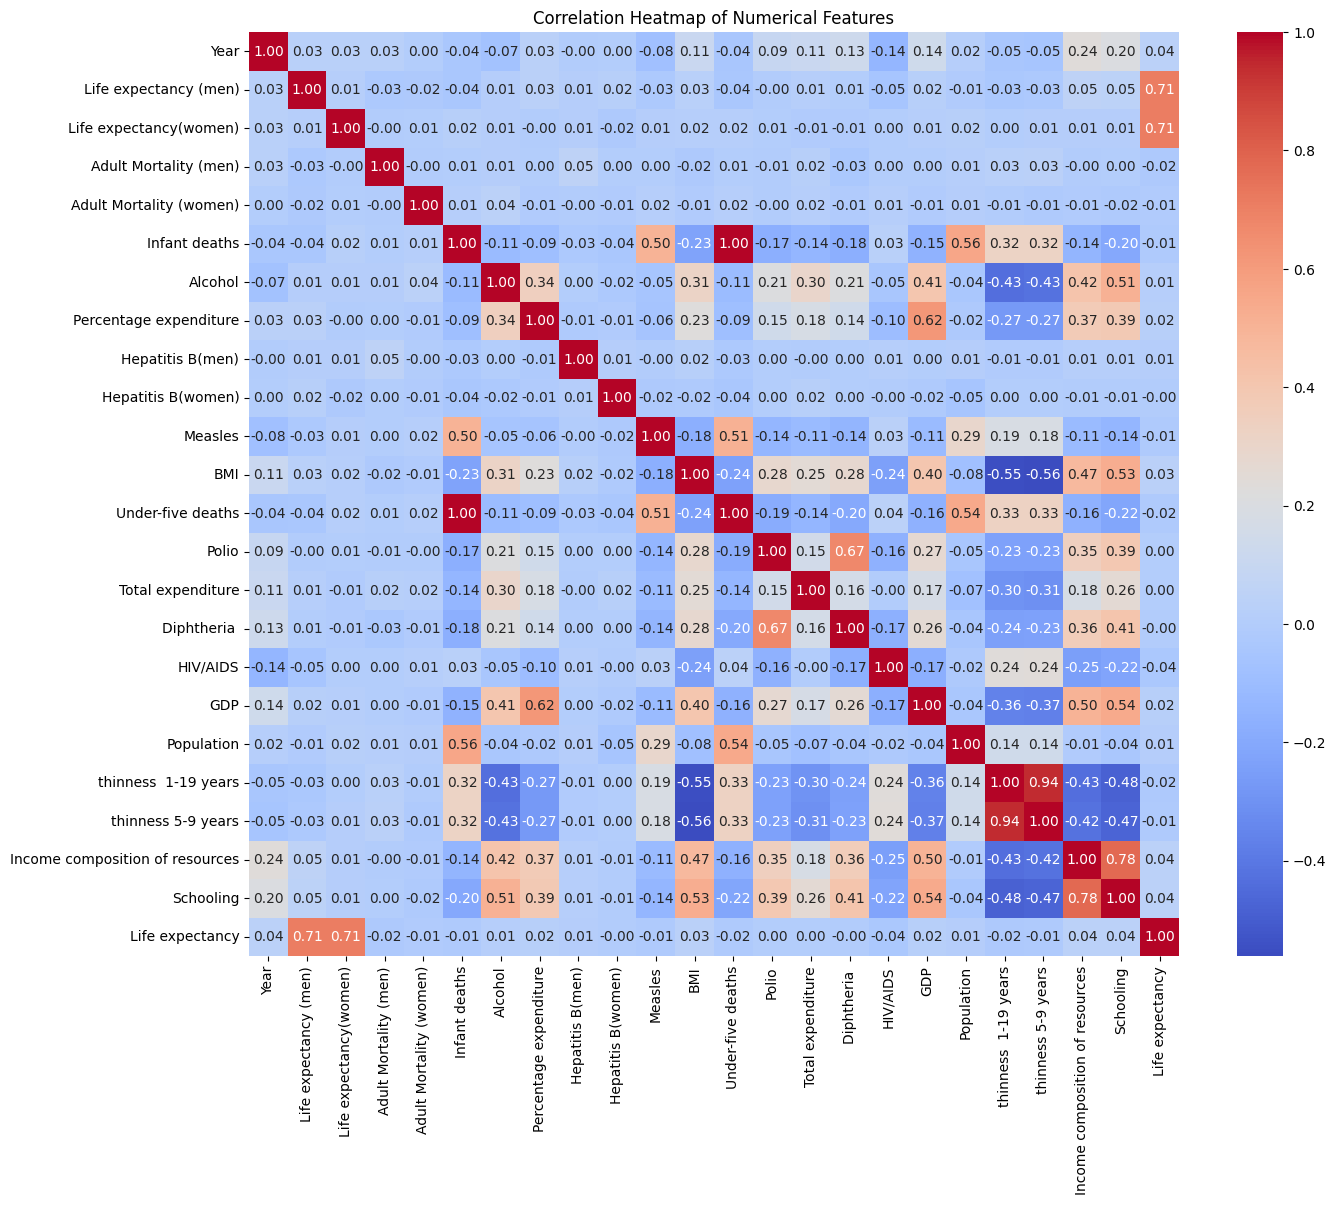

In [108]:
# ===============================
# STEP 6 — Scatterplots and Correlation Heatmap (EDA)
# ===============================
features = ['Year','Adult Mortality (men)','Infant deaths','Alcohol','Percentage expenditure',
            'Hepatitis B(men)','Measles','BMI','Under-five deaths','Polio',
            'Total expenditure','Diphtheria','HIV/AIDS','GDP','Population',
            'thinness  1-19 years','thinness 5-9 years',
            'Income composition of resources','Schooling']

print('Scatterplots vs. Life Expectancy:')
for col in features:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.scatterplot(data=df, x=col, y='Life expectancy')
        plt.title(f'Life Expectancy vs. {col}')
        plt.xlabel(col)
        plt.ylabel('Life Expectancy')
        plt.show()
    else:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping scatterplot for this column.")

print('\nCorrelation Heatmap of Numerical Features:')
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(15,12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [110]:
# ===============================
# STEP 7 — Duplicate Removal & Encoding
# ===============================
df = df.drop_duplicates()
print(f'Duplicates removed. New shape: {df.shape}')

# The 'Country' and 'Status' columns appear to be already one-hot encoded in the dataset.
# Removing the pd.get_dummies call to avoid KeyError.
# df = pd.get_dummies(df, columns=['Country', 'Status'], drop_first=True)
# print('Categorical columns encoded using one-hot encoding.')

# ===============================
# FINAL OUTPUT
# ===============================
print('\nFinal DataFrame Shape:', df.shape)
print('Final DataFrame Head:')
display(df.head())

Duplicates removed. New shape: (2938, 217)

Final DataFrame Shape: (2938, 217)
Final DataFrame Head:


,Year,Life expectancy (men),Life expectancy(women),Adult Mortality (men),Adult Mortality (women),Infant deaths,Alcohol,Percentage expenditure,Hepatitis B(men),Hepatitis B(women),...,Country_United States of America,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela (Bolivarian Republic of),Country_Viet Nam,Country_Yemen,Country_Zambia,Country_Zimbabwe,Status_Developing
0,2015.0,70.0,66.0,67.0,65.0,62.0,0.01,71.279624,40.0,40.0,...,False,False,False,False,False,False,False,False,False,True
1,2014.0,59.0,67.0,73.0,85.0,64.0,0.01,73.523582,20.0,43.0,...,False,False,False,False,False,False,False,False,False,True
2,2013.0,79.0,51.0,87.0,67.0,66.0,0.01,73.219243,25.0,39.0,...,False,False,False,False,False,False,False,False,False,True
3,2012.0,65.0,81.0,63.0,91.0,69.0,0.01,78.184215,54.0,42.0,...,False,False,False,False,False,False,False,False,False,True
4,2011.0,76.0,75.0,57.0,72.0,71.0,0.01,7.097109,48.0,24.0,...,False,False,False,False,False,False,False,False,False,True
